# COVID-19 Predictive Model
## Jess Denton
### Module: DC3DMN

## Table of Contents
1. Academic Integrity Statement
2. Introduction
3. Ingesting and Preparing the Data
4. Exploratory Data Analysis
4. Building the Model
5. Testing and Iterations
6. Conclusion
7. References
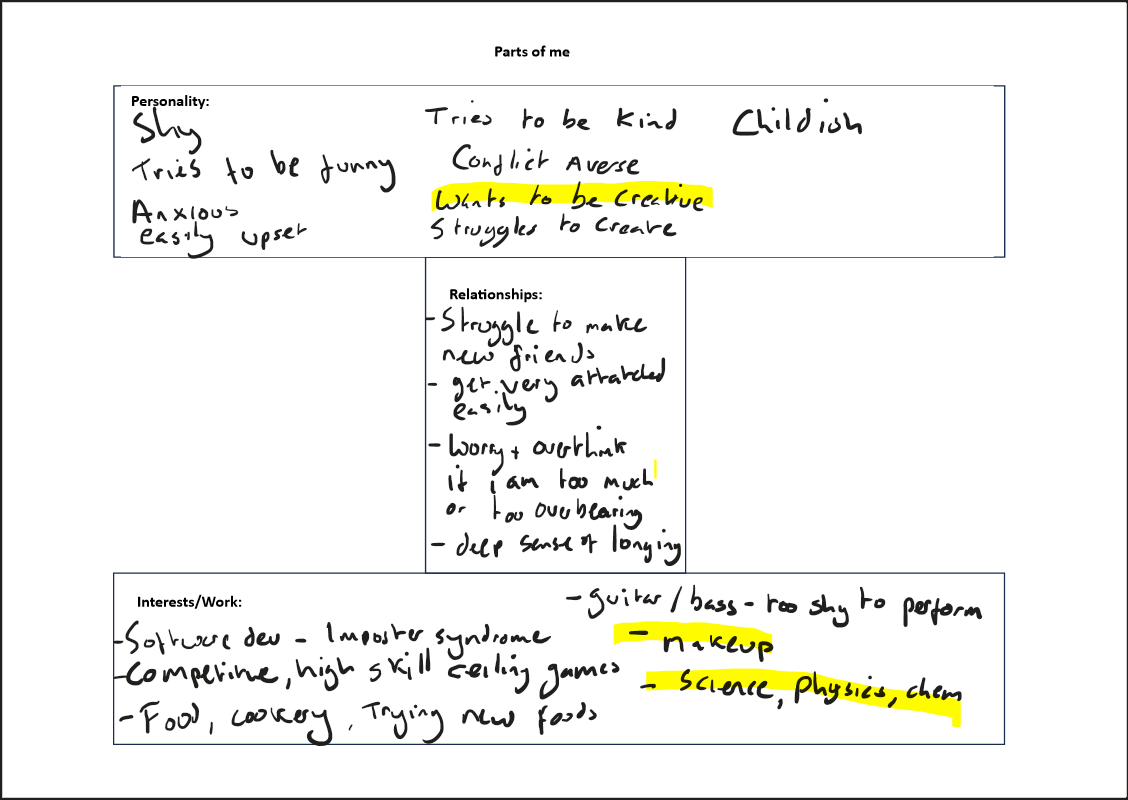

### Academic Integrity Statement
 I declare that I have personally prepared this assignment. The work is my own, carried out personally by me unless otherwise stated and has not been generated using Artificial Intelligence tools unless specified as a clearly stated approved component of the assessment brief. All sources of information, including quotations, are acknowledged by means of the appropriate citations and references. I declare that this work has not gained credit previously for another module at this or another University.

I understand that plagiarism, collusion, copying another student and commissioning (which for the avoidance of doubt includes the use of essay mills and other paid for assessment writing services, as well as unattributed use of work generated by Artificial Intelligence tools) are regarded as offences against the University’s Assessment Regulations and may result in formal disciplinary proceedings.

### Introduction
This notebook will analyse a provided data extract of COVID-19 test results to train a machine learning model and provide predictions over a similar unseen dataset. The code sections will be applying data mining techniques in order to extract valuable features from the data set and train a machine learning algorithm on them. The report blocks will explain the rationale, underlying theory and reflect on the processes applied to break down and analyse the dataset.
Data mining is defined as *'the use of machine learning and statistical analysis to uncover patterns and other valuable information from large data sets' (Holdsworth, J. 2024)*.

## Ingesting and Preparing the Data

### Raw Data & Imports
The first part of data mining is to understand the dataset that will be used. The sample data extract has 3999 rows across 108 columns. 105 of the columns contain features, these are columns that contain clinical measurements that case represent a test, symptom or observation for a specific record. 2 of the columns contain obfuscated patient information and the final column contains the result of a COVID-19 test. The dataset has a mix of types of data (not to be confused with their computational dtype). There is interval data such as column feat_Urine - pH, where there is a numeric quality to the data, but where certain mathematical operations do not make sense (sum or product operations) but the difference between values does make sense. pH is a great example of this as adding or multiplying different values in the pH column is meaningless, but the difference between them could help identify who is more likely to have a positive COVID-19 assay. There are also many continuous attributes present, where the attributes have Real number values. This data type makes up the bulk of the dataset. Finally, there are nominal attributes, the most important of which is the COVID-19 Test result column, which has a binary state of positive or negative. This will be the value that the model is tasked to predict for unseen sets of data. Currently, the dataset provides rich data, but poor information. Which means it is difficult to draw conclusions or predict results with it in its raw form. It is difficult for a human to parse large data sets and extract meaningful conclusions and the data mining process aims to reduce that gap, in this case providing an algorithm that will be used to predict cases of COVID-19 among a population.

 In this case the aim is to make a model that carries out a form of binary classification and predict either a positive or negative COVID-19 assay. Classification is a type of data mining that aims to isolate features that have high influence over the value of a nominal class, and use them to predict values from that nominal class from an unseen set of feature values. *Geeks for Geeks* define classification as; *'Classification in data mining is a supervised learning approach used to assign data points into predefined classes based on their features. By analysing labelled historical data, classification algorithms learn patterns and relationships that enable them to categorize new, unseen data accurately.'(GeeksForGeeks, 2018)*. The first step is to ingest this data into the notebook using the python pandas library.

Pandas *is a fast, powerful, flexible and easy to use open source data analysis and manipulation tool (Pandas, 2019).* It allows construction of data frame objects, which contain multiple series of data with labels (columns) and indexes (rows). This becomes a manipulatable representation of all the data contained within the CSV file. It also interacts with many of the other libraries that will be used for visualisation and machine learning, which makes it highly versatile and a key tool for any data mining effort that uses python. Firstly pandas needs to be imported, as well as all other libraries that will be used throughout the notebook.


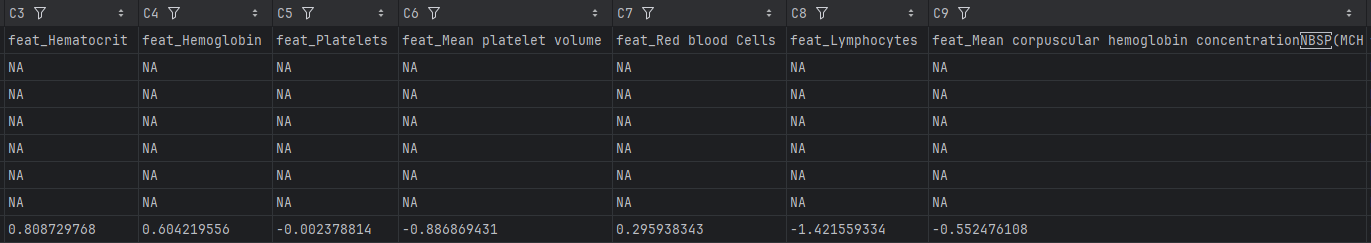

In [263]:
#Run imports for libraries to be used
import pandas as pd
import json
from sklearn.experimental import enable_iterative_imputer #required for iterative imputer to run
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import IterativeImputer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import f1_score
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import PowerTransformer
import re
import missingno as msno
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
import sklearn
from scipy.cluster.hierarchy import fcluster
from sklearn.neighbors import KNeighborsClassifier, BallTree
from imblearn.over_sampling import ADASYN
from xgboost import XGBClassifier
from sklearn.preprocessing import OneHotEncoder
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import GridSearchCV
from skopt.space import Real, Integer
from skopt import BayesSearchCV

#Set up options for pandas return functions
pd.options.display.max_rows = 100
pd.options.display.max_columns = 110
sklearn.set_config(transform_output="pandas")

### Ingesting the raw CSV
The data extract provided is a CSV file with ANSI encoding. Pandas creates data frame objects which hold the ingested data in a 2-dimensional mutable array. The 'read_csv' method from Pandas is invoked to load the data into a dataframe, using a separate JSON schema to specify data types for each column in the CSV to make the data simpler to work with. Usually this method will attempt to infer the data type (also referred to as dtypes) for each column, but this can lead to unexpected dtypes in columns which may result in errors with data processing further in the process. Using a schema removes ambiguity and reduces the number of casts done in the processing chain, which subsequently reduces the opportunities to induce errors. There is also an additional parameter to cast values to True or False for boolean columns, accounting for the most common ones in the dataset.

In [264]:
#load the schema
with open('ingest_schema.json') as f:
    schema = json.load(f)

#Use the schema and other params to ingest the csv
df_all = pd.read_csv(
    filepath_or_buffer ="CW_data.csv",
    encoding='ANSI',
    dtype = schema,
    true_values = ["positive", "detected", "TRUE", 'present'],
    false_values = ["negative", "not_detected", "FALSE", 'absent'],
    na_values = ["not_done", "NA"],
    on_bad_lines = "warn"
    )
#Check the head, shape and class distribution of the dataframe
class_counts = df_all['SARS-Cov-2 exam result'].value_counts()
class_ratio = class_counts / len(df_all)
print(f'Shape of df_all is: \n{df_all.shape} \nand the class distribution is: \n{class_counts} \nwith a bias of \n{class_ratio}')
df_all.head(10)

Shape of df_all is: 
(3999, 108) 
and the class distribution is: 
SARS-Cov-2 exam result
False    3598
True      401
Name: count, dtype: Int64 
with a bias of 
SARS-Cov-2 exam result
False    0.899725
True     0.100275
Name: count, dtype: Float64


,Patient ID,Patient age quantile,feat_Hematocrit,feat_Hemoglobin,feat_Platelets,feat_Mean platelet volume,feat_Red blood Cells,feat_Lymphocytes,feat_Mean corpuscular hemoglobin concentration (MCHC),feat_Leukocytes,feat_Basophils,feat_Mean corpuscular hemoglobin (MCH),feat_Eosinophils,feat_Mean corpuscular volume (MCV),feat_Monocytes,feat_Red blood cell distribution width (RDW),feat_Serum Glucose,feat_Respiratory Syncytial Virus,feat_Influenza A,feat_Influenza B,feat_Parainfluenza 1,feat_CoronavirusNL63,feat_Rhinovirus/Enterovirus,feat_Mycoplasma pneumoniae,feat_Coronavirus HKU1,feat_Parainfluenza 3,feat_Chlamydophila pneumoniae,feat_Adenovirus,feat_Parainfluenza 4,feat_Coronavirus229E,feat_CoronavirusOC43,feat_Inf A H1N1 2009,feat_Bordetella pertussis,feat_Metapneumovirus,feat_Parainfluenza 2,feat_Neutrophils,feat_Urea,feat_Proteina C reativa mg/dL,feat_Creatinine,feat_Potassium,feat_Sodium,"feat_Influenza B, rapid test","feat_Influenza A, rapid test",feat_Alanine transaminase,feat_Aspartate transaminase,feat_Gamma-glutamyltransferase,feat_Total Bilirubin,feat_Direct Bilirubin,feat_Indirect Bilirubin,feat_Alkaline phosphatase,feat_Ionized calcium,feat_Strepto A,feat_Magnesium,feat_pCO2 (venous blood gas analysis),feat_Hb saturation (venous blood gas analysis),feat_Base excess (venous blood gas analysis),feat_pO2 (venous blood gas analysis),feat_Fio2 (venous blood gas analysis),feat_Total CO2 (venous blood gas analysis),feat_pH (venous blood gas analysis),feat_HCO3 (venous blood gas analysis),feat_Rods #,feat_Segmented,feat_Promyelocytes,feat_Metamyelocytes,feat_Myelocytes,feat_Myeloblasts,feat_Urine - Esterase,feat_Urine - Aspect,feat_Urine - pH,feat_Urine - Hemoglobin,feat_Urine - Bile pigments,feat_Urine - Ketone Bodies,feat_Urine - Nitrite,feat_Urine - Density,feat_Urine - Urobilinogen,feat_Urine - Protein,feat_Urine - Sugar,feat_Urine - Leukocytes,feat_Urine - Crystals,feat_Urine - Red blood cells,feat_Urine - Hyaline cylinders,feat_Urine - Granular cylinders,feat_Urine - Yeasts,feat_Urine - Color,feat_Partial thromboplastin time (PTT),feat_Relationship (Patient/Normal),feat_International normalized ratio (INR),feat_Lactic Dehydrogenase,"feat_Prothrombin time (PT), Activity",feat_Vitamin B12,feat_Creatine phosphokinase (CPK),feat_Ferritin,feat_Arterial Lactic Acid,feat_Lipase dosage,feat_D-Dimer,feat_Albumin,feat_Hb saturation (arterial blood gases),feat_pCO2 (arterial blood gas analysis),feat_Base excess (arterial blood gas analysis),feat_pH (arterial blood gas analysis),feat_Total CO2 (arterial blood gas analysis),feat_HCO3 (arterial blood gas analysis),feat_pO2 (arterial blood gas analysis),feat_Arteiral Fio2,feat_Phosphor,feat_ctO2 (arterial blood gas analysis),SARS-Cov-2 exam result
0,715f6bdee94fdd7,9,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,False,False,True,False,NaN,False,False,False,False,False,False,False,True,False,False,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,NaN,<NA>,NaN,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False
1,4495129155a2cc9,9,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,NaN,<NA>,NaN,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False
2,af17911deea7b00,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<N

The data is successfully loaded into a dataframe and immediately the class imbalance is apparent. The imbalance is roughly 90:1 for Negative vs Positive COVID-19 test results. This will need to be addressed later when fitting models. Aside from that, printing the head of the dataframe shows the top 10 rows and all columns of the data as pandas has stored it. This is a quick and simple way for a human to verify that the data is generally as expected. For example, it would be easy to see if something had errored if a column with mostly numerical values suddenly gained a string as an entry. This is not foolproof as it only looks at a tiny fraction of the data, and even still the size and complexity of the data still means that it is not suitable for human interpretation.

The next step normalises the column headers to make sure they are callable by label, as they are case sensitive and must be implicitly named in order to address individual columns. The code strips any additional spaces and removes any invisible ones also. This will also be used to normalise any incoming data for the model to predict over once they are trained.

In [265]:
#clean column labels for invisible space characters, create function for use on unseen data.
def clean_cols(df):
    # Remove occurrences of \xa0
    df.columns = [re.sub(r'\s+', ' ', col).strip() for col in df.columns]
    return df
df_all = clean_cols(df_all)
# double check columns are still there as expected
print(f'df_all shape post column header clean is: {df_all.shape}')
df_all.head()

df_all shape post column header clean is: (3999, 108)


,Patient ID,Patient age quantile,feat_Hematocrit,feat_Hemoglobin,feat_Platelets,feat_Mean platelet volume,feat_Red blood Cells,feat_Lymphocytes,feat_Mean corpuscular hemoglobin concentration (MCHC),feat_Leukocytes,feat_Basophils,feat_Mean corpuscular hemoglobin (MCH),feat_Eosinophils,feat_Mean corpuscular volume (MCV),feat_Monocytes,feat_Red blood cell distribution width (RDW),feat_Serum Glucose,feat_Respiratory Syncytial Virus,feat_Influenza A,feat_Influenza B,feat_Parainfluenza 1,feat_CoronavirusNL63,feat_Rhinovirus/Enterovirus,feat_Mycoplasma pneumoniae,feat_Coronavirus HKU1,feat_Parainfluenza 3,feat_Chlamydophila pneumoniae,feat_Adenovirus,feat_Parainfluenza 4,feat_Coronavirus229E,feat_CoronavirusOC43,feat_Inf A H1N1 2009,feat_Bordetella pertussis,feat_Metapneumovirus,feat_Parainfluenza 2,feat_Neutrophils,feat_Urea,feat_Proteina C reativa mg/dL,feat_Creatinine,feat_Potassium,feat_Sodium,"feat_Influenza B, rapid test","feat_Influenza A, rapid test",feat_Alanine transaminase,feat_Aspartate transaminase,feat_Gamma-glutamyltransferase,feat_Total Bilirubin,feat_Direct Bilirubin,feat_Indirect Bilirubin,feat_Alkaline phosphatase,feat_Ionized calcium,feat_Strepto A,feat_Magnesium,feat_pCO2 (venous blood gas analysis),feat_Hb saturation (venous blood gas analysis),feat_Base excess (venous blood gas analysis),feat_pO2 (venous blood gas analysis),feat_Fio2 (venous blood gas analysis),feat_Total CO2 (venous blood gas analysis),feat_pH (venous blood gas analysis),feat_HCO3 (venous blood gas analysis),feat_Rods #,feat_Segmented,feat_Promyelocytes,feat_Metamyelocytes,feat_Myelocytes,feat_Myeloblasts,feat_Urine - Esterase,feat_Urine - Aspect,feat_Urine - pH,feat_Urine - Hemoglobin,feat_Urine - Bile pigments,feat_Urine - Ketone Bodies,feat_Urine - Nitrite,feat_Urine - Density,feat_Urine - Urobilinogen,feat_Urine - Protein,feat_Urine - Sugar,feat_Urine - Leukocytes,feat_Urine - Crystals,feat_Urine - Red blood cells,feat_Urine - Hyaline cylinders,feat_Urine - Granular cylinders,feat_Urine - Yeasts,feat_Urine - Color,feat_Partial thromboplastin time (PTT),feat_Relationship (Patient/Normal),feat_International normalized ratio (INR),feat_Lactic Dehydrogenase,"feat_Prothrombin time (PT), Activity",feat_Vitamin B12,feat_Creatine phosphokinase (CPK),feat_Ferritin,feat_Arterial Lactic Acid,feat_Lipase dosage,feat_D-Dimer,feat_Albumin,feat_Hb saturation (arterial blood gases),feat_pCO2 (arterial blood gas analysis),feat_Base excess (arterial blood gas analysis),feat_pH (arterial blood gas analysis),feat_Total CO2 (arterial blood gas analysis),feat_HCO3 (arterial blood gas analysis),feat_pO2 (arterial blood gas analysis),feat_Arteiral Fio2,feat_Phosphor,feat_ctO2 (arterial blood gas analysis),SARS-Cov-2 exam result
0,715f6bdee94fdd7,9,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,False,False,True,False,NaN,False,False,False,False,False,False,False,True,False,False,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,NaN,<NA>,NaN,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False
1,4495129155a2cc9,9,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,NaN,<NA>,NaN,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False
2,af17911deea7b00,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<N

### Preprocessing
Although the data is now ingested, it will need a number of preprocessing steps before it is fit for training models on. There are some obvious steps to take with the data initially, but other steps will need visualisations or other aggregations in order to become visible. The preprocessing section will address outliers, missing values and insuring the dtypes are all able to be interpreted numerically, which may require casting of ordinal values to a numerical equivalent. Firstly, while an ID column is very useful when data is stored in a database or when the ability to look up a single record is a requirement, it is practically useless in a machine learning context. This is because it has no bearing on the class of a record. It should be dropped from any dataset the system is predicting or training on.

It is also evident from looking at the head of the data frame that there is a large proportion of missing values (values of NaN or <NA>) in the dataset. This poses an issue for data mining, as noted in the Korean Journal of Anesthesiology,*"...the absence of data reduces statistical power, which refers to the probability that the test will reject the null hypothesis when it is false. Second, the lost data can cause bias in the estimation of parameters. Third, it can reduce the representativeness of the samples. Fourth, it may complicate the analysis of the study. Each of these distortions may threaten the validity of the trials and can lead to invalid conclusions" (Kang, H. 2013).* The issue of missing data is common across all fields of data engineering (especially for medical datasets) and when unhandled can lead to 1 or all of the problems laid out above. The next preprocessing step will look to remove columns and rows with large amounts of missing values in order to increase the statistical power, without overly reducing the resolution of the dataset. Many other missing values will remain and be handled later via other methods, as removing all missing values from the dataset is impossible if it is to retain any statistical relevance.
To start, some columns have either got only NaN values or values that are all identical. Columns that are all NaN are useless for data mining as they cannot be used as a predictor for the model. The same goes for columns where the value is all equal but not NaN, as these columns have no variance they can be discounted as being influential over the COVID-19 test result.

In this dataset there are 5 columns that have only got 1 unique value contained in them, and they all happen to be missing value columns. These can be safely dropped from the dataframe. The same logic should be applied for rows with all values missing also, as their classification has no feature information that can be used for modelling, meaning its class value would only serve to increase the already heavily biased class totals. Considerations need to be made to exclude the age quantile column and the class column, as they are the only columns populated for every record.

In [266]:
def preprocess(df):
    #Remove the patient ID column and check the rest of the data is as expected
    df.drop('Patient ID', axis = 1, inplace = True)
    #Find all columns with only a single unique value in the column
    df_single_values =  df.loc[:, df.nunique(dropna = False) == 1]
    #Drop all columns with 1 or less unique values from df_all
    df = df.drop(columns = df_single_values.columns)
    #Ignore the patient quantile and exam result
    ignored_cols = ["Patient age quantile", "SARS-Cov-2 exam result"]
    all_feats_cols = df.columns.difference(ignored_cols)
    #Drop all rows that are fully missing all feature values
    df = df.dropna(how = "all", subset = all_feats_cols)
    #check the new shape of the dataframe to see how many rows were dropped
    print(f'The current shape of df after preprocessing is: {df.shape}')
    return df, df_single_values.columns
df_all, single_values = preprocess(df_all)

The current shape of df after preprocessing is: (1495, 100)


The next thing to handle is the columns labeled with dytpe string from the ingestion schema. Machine learning algorithms work best (and often only work at all) on numeric values. Using a table to visually inspect the contents of each column with applicable dtype will determine the strategy required to address each one.

In [267]:
# Identify string/object/category columns and look at what they actually contain
df_string_cols = df_all.select_dtypes(include=['object', 'category'])

print(f"{'COLUMN NAME':<35}  {'UNIQUE VALUES'}")
for col in df_string_cols.columns:
    unique_list = df_all[col].unique().tolist()
    #Format the column name and the list for better readability
    col_label = f"**{col}**"
    values_str = ", ".join([str(val) for val in unique_list])
    # Print the column and its values (trunc down to stop going on forever)
    if len(values_str) > 100:
        values_str = values_str[:97] + "..."
    print(f"{col:<35} | {values_str}")
df_all.head(1)

COLUMN NAME                          UNIQUE VALUES
feat_Urine - Aspect                 | nan, clear, cloudy, lightly_cloudy
feat_Urine - Urobilinogen           | nan, normal
feat_Urine - Leukocytes             | nan, 2000, <1000, 124000, 29000, 4000, 5000, 38000, 3000, 4600, 23000, 77000, 7000, 1000, 28000, ...
feat_Urine - Crystals               | nan, Ausentes, Urato Amorfo +++, Oxalato de Cálcio +++, Oxalato de Cálcio -++
feat_Urine - Color                  | nan, yellow, light_yellow, citrus_yellow


,Patient age quantile,feat_Hematocrit,feat_Hemoglobin,feat_Platelets,feat_Mean platelet volume,feat_Red blood Cells,feat_Lymphocytes,feat_Mean corpuscular hemoglobin concentration (MCHC),feat_Leukocytes,feat_Basophils,feat_Mean corpuscular hemoglobin (MCH),feat_Eosinophils,feat_Mean corpuscular volume (MCV),feat_Monocytes,feat_Red blood cell distribution width (RDW),feat_Serum Glucose,feat_Respiratory Syncytial Virus,feat_Influenza A,feat_Influenza B,feat_Parainfluenza 1,feat_CoronavirusNL63,feat_Rhinovirus/Enterovirus,feat_Coronavirus HKU1,feat_Parainfluenza 3,feat_Chlamydophila pneumoniae,feat_Adenovirus,feat_Parainfluenza 4,feat_Coronavirus229E,feat_CoronavirusOC43,feat_Inf A H1N1 2009,feat_Bordetella pertussis,feat_Metapneumovirus,feat_Parainfluenza 2,feat_Neutrophils,feat_Urea,feat_Proteina C reativa mg/dL,feat_Creatinine,feat_Potassium,feat_Sodium,"feat_Influenza B, rapid test","feat_Influenza A, rapid test",feat_Alanine transaminase,feat_Aspartate transaminase,feat_Gamma-glutamyltransferase,feat_Total Bilirubin,feat_Direct Bilirubin,feat_Indirect Bilirubin,feat_Alkaline phosphatase,feat_Ionized calcium,feat_Strepto A,feat_Magnesium,feat_pCO2 (venous blood gas analysis),feat_Hb saturation (venous blood gas analysis),feat_Base excess (venous blood gas analysis),feat_pO2 (venous blood gas analysis),feat_Total CO2 (venous blood gas analysis),feat_pH (venous blood gas analysis),feat_HCO3 (venous blood gas analysis),feat_Rods #,feat_Segmented,feat_Promyelocytes,feat_Metamyelocytes,feat_Myelocytes,feat_Myeloblasts,feat_Urine - Esterase,feat_Urine - Aspect,feat_Urine - pH,feat_Urine - Hemoglobin,feat_Urine - Bile pigments,feat_Urine - Ketone Bodies,feat_Urine - Density,feat_Urine - Urobilinogen,feat_Urine - Protein,feat_Urine - Leukocytes,feat_Urine - Crystals,feat_Urine - Red blood cells,feat_Urine - Hyaline cylinders,feat_Urine - Granular cylinders,feat_Urine - Yeasts,feat_Urine - Color,feat_Relationship (Patient/Normal),feat_International normalized ratio (INR),feat_Lactic Dehydrogenase,feat_Vitamin B12,feat_Creatine phosphokinase (CPK),feat_Ferritin,feat_Arterial Lactic Acid,feat_Lipase dosage,feat_Albumin,feat_Hb saturation (arterial blood gases),feat_pCO2 (arterial blood gas analysis),feat_Base excess (arterial blood gas analysis),feat_pH (arterial blood gas analysis),feat_Total CO2 (arterial blood gas analysis),feat_HCO3 (arterial blood gas analysis),feat_pO2 (arterial blood gas analysis),feat_Arteiral Fio2,feat_Phosphor,feat_ctO2 (arterial blood gas analysis),SARS-Cov-2 exam result
0,9,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False


The above table shows there are 3 columns that have categoric data in them; urine aspect, urine crystals and urine colour. There is also a column of integer values, but there are entries for '<1000' which mean that the entire urine leukocytes column had to be imported as a string. Additionally, there are 2 columns that have 'normal' and 'Ausentes' as values. These couldn't be accounted for in the ingestion schema and need to be manually mapped now. It is important to preserve NaN values, so that will also be accounted for during the processing. For the leukocytes column, the values of '<1000' can be replaced with 999 and then the whole column can be recast as a float, allowing for numerical processing. The values of 'normal' and 'Ausentes' can be mapped and replaced accordingly with 0 values. Their columns cannot be recast as a specific type currently but will be handled in the full dataframe numeric cast later. The categoric columns need to be handled via One-hot encoding, which will be applied post test-train split to minimise data leakage.

In [268]:
#keep an eye on the shape to make sure nothing is going wrong
print(f'shape pre casting & mapping is: {df_all.shape}')
#Handle these columns by converting them to numerical values where possible.
def input_mapping(df):
    df['feat_Urine - Leukocytes'] = df['feat_Urine - Leukocytes'].replace('<1000', 999).astype('Float64')
    #normal mapping
    mapping = { 'normal': 0, 'Ausentes' : 0}
    df = df.replace(mapping)
    return df
df_all = input_mapping(df_all)
df_all.head(1)

shape pre casting & mapping is: (1495, 100)


C:\Users\Jess\AppData\Local\Temp\ipykernel_32812\3666694542.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(mapping)


,Patient age quantile,feat_Hematocrit,feat_Hemoglobin,feat_Platelets,feat_Mean platelet volume,feat_Red blood Cells,feat_Lymphocytes,feat_Mean corpuscular hemoglobin concentration (MCHC),feat_Leukocytes,feat_Basophils,feat_Mean corpuscular hemoglobin (MCH),feat_Eosinophils,feat_Mean corpuscular volume (MCV),feat_Monocytes,feat_Red blood cell distribution width (RDW),feat_Serum Glucose,feat_Respiratory Syncytial Virus,feat_Influenza A,feat_Influenza B,feat_Parainfluenza 1,feat_CoronavirusNL63,feat_Rhinovirus/Enterovirus,feat_Coronavirus HKU1,feat_Parainfluenza 3,feat_Chlamydophila pneumoniae,feat_Adenovirus,feat_Parainfluenza 4,feat_Coronavirus229E,feat_CoronavirusOC43,feat_Inf A H1N1 2009,feat_Bordetella pertussis,feat_Metapneumovirus,feat_Parainfluenza 2,feat_Neutrophils,feat_Urea,feat_Proteina C reativa mg/dL,feat_Creatinine,feat_Potassium,feat_Sodium,"feat_Influenza B, rapid test","feat_Influenza A, rapid test",feat_Alanine transaminase,feat_Aspartate transaminase,feat_Gamma-glutamyltransferase,feat_Total Bilirubin,feat_Direct Bilirubin,feat_Indirect Bilirubin,feat_Alkaline phosphatase,feat_Ionized calcium,feat_Strepto A,feat_Magnesium,feat_pCO2 (venous blood gas analysis),feat_Hb saturation (venous blood gas analysis),feat_Base excess (venous blood gas analysis),feat_pO2 (venous blood gas analysis),feat_Total CO2 (venous blood gas analysis),feat_pH (venous blood gas analysis),feat_HCO3 (venous blood gas analysis),feat_Rods #,feat_Segmented,feat_Promyelocytes,feat_Metamyelocytes,feat_Myelocytes,feat_Myeloblasts,feat_Urine - Esterase,feat_Urine - Aspect,feat_Urine - pH,feat_Urine - Hemoglobin,feat_Urine - Bile pigments,feat_Urine - Ketone Bodies,feat_Urine - Density,feat_Urine - Urobilinogen,feat_Urine - Protein,feat_Urine - Leukocytes,feat_Urine - Crystals,feat_Urine - Red blood cells,feat_Urine - Hyaline cylinders,feat_Urine - Granular cylinders,feat_Urine - Yeasts,feat_Urine - Color,feat_Relationship (Patient/Normal),feat_International normalized ratio (INR),feat_Lactic Dehydrogenase,feat_Vitamin B12,feat_Creatine phosphokinase (CPK),feat_Ferritin,feat_Arterial Lactic Acid,feat_Lipase dosage,feat_Albumin,feat_Hb saturation (arterial blood gases),feat_pCO2 (arterial blood gas analysis),feat_Base excess (arterial blood gas analysis),feat_pH (arterial blood gas analysis),feat_Total CO2 (arterial blood gas analysis),feat_HCO3 (arterial blood gas analysis),feat_pO2 (arterial blood gas analysis),feat_Arteiral Fio2,feat_Phosphor,feat_ctO2 (arterial blood gas analysis),SARS-Cov-2 exam result
0,9,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False


In data mining and machine learning, data leakage is one of the top priorities to eliminate. Data leakage is defined as *"...when a model uses information during training that wouldn't be available at the time of prediction" (Mucci, 2024).* If leakage occurs then a model looks accurate until it is deployed onto unseen data, at which point it yields inaccurate results and false insights. In order to mitigate data leakage, data miners have to carry out data processing steps in particular orders, always trying to minimise the inclusion of future information to keep the model trained as representatively as possible. One of the key methods for this is using a test-train split. With the full dataset ingested, splitting it into 2 parts allows the model to be trained on one set of data, while remaining completely in the dark about the other set. This helps to properly evaluate a models performance on unseen data sets. Any part of the model that is being fitted, will only be fitted to the training set. Any transformations that subsequently need to be applied will be applied to both the training and test sets, to make sure that the dimensionality and shape remains the same. In this case, with a huge class imbalance the test-train split needs to be stratified on the classifiers, making sure that the ratio of classifiers in each split is maintained.

In [269]:
# Split out the classifiers and predictors
df_classifiers = df_all['SARS-Cov-2 exam result']
df_predictors = df_all.drop(['SARS-Cov-2 exam result'], axis = 1).copy()
#Carry out test train split
df_predictor_train, df_predictor_test, df_classifier_train, df_classifier_test = train_test_split(df_predictors, df_classifiers, test_size = 0.2, stratify = df_classifiers, random_state = 1)
print(f'The shape of the test-train splits are:\nTraining Predictors: {df_predictor_train.shape}\nTraining Classifiers: {df_classifier_train.shape}\nTest Predictors: {df_predictor_test.shape}\nTest Classifiers: {df_classifier_test.shape}')

The shape of the test-train splits are:
Training Predictors: (1196, 99)
Training Classifiers: (1196,)
Test Predictors: (299, 99)
Test Classifiers: (299,)


The categoric columns identified earlier will now be encoded via One Hot Encoding, which *'...is a technique for representing categorical data as numerical vectors, where each unique category is represented by a binary column with a value of 1 indicating its presence and 0 indicating its absence (Rojo-Echeburúa, 2024).* This is a step that prevents data being lost from the categoric columns, but still allows numerical operations to be applied. It does so by splitting out each category in a feature into its own binary column, where any entries for that category are marked as 1 and entries for the other categories are marked 0. This increases the number of columns in the dataset by the number of categoric features and the amount of categories in each feature. The encoder is fitted on the train set and transforms both train and test predictor sets. The classifiers are not affected by this in any way.

In [270]:
categorical_cols = ['feat_Urine - Aspect','feat_Urine - Crystals','feat_Urine - Color']
def one_hot_encoder(dfx, dfx_test):
    #convert to all singular column dtype to make ohencoder happy
    train_converted = dfx[categorical_cols].astype(str).replace('nan', 'missing')
    test_converted = dfx_test[categorical_cols].astype(str).replace('nan', 'missing')
    # utilise one-hot encoding to make these columns split out into numeric values columns instead.
    encoder = OneHotEncoder(handle_unknown = 'ignore', dtype = 'bool', sparse_output= False)
    encoded_train = encoder.fit_transform(train_converted)
    encoded_test = encoder.transform(test_converted)
    #df conversion
    encoded_cols = encoder.get_feature_names_out(categorical_cols)
    dfx_encoded = pd.DataFrame(encoded_train, columns = encoded_cols, index = dfx.index)
    dfx_test_encoded = pd.DataFrame(encoded_test, columns = encoded_cols, index = dfx_test.index)
    #add to og dataframes
    dfx_new = dfx.drop(columns = categorical_cols).join(dfx_encoded)
    dfx_test_new = dfx_test.drop(columns = categorical_cols).join(dfx_test_encoded)
    return dfx_new, dfx_test_new, encoder

df_predictor_train, df_predictor_test, encoder = one_hot_encoder(df_predictor_train, df_predictor_test)
print(f'The shape of the test-train splits post OneHot Encoding are:\nTraining Predictors: {df_predictor_train.shape}\nTraining Classifiers: {df_classifier_train.shape}\nTest Predictors: {df_predictor_test.shape}\nTest Classifiers: {df_classifier_test.shape}')

df_predictor_train.head()

The shape of the test-train splits post OneHot Encoding are:
Training Predictors: (1196, 106)
Training Classifiers: (1196,)
Test Predictors: (299, 106)
Test Classifiers: (299,)


,Patient age quantile,feat_Hematocrit,feat_Hemoglobin,feat_Platelets,feat_Mean platelet volume,feat_Red blood Cells,feat_Lymphocytes,feat_Mean corpuscular hemoglobin concentration (MCHC),feat_Leukocytes,feat_Basophils,feat_Mean corpuscular hemoglobin (MCH),feat_Eosinophils,feat_Mean corpuscular volume (MCV),feat_Monocytes,feat_Red blood cell distribution width (RDW),feat_Serum Glucose,feat_Respiratory Syncytial Virus,feat_Influenza A,feat_Influenza B,feat_Parainfluenza 1,feat_CoronavirusNL63,feat_Rhinovirus/Enterovirus,feat_Coronavirus HKU1,feat_Parainfluenza 3,feat_Chlamydophila pneumoniae,feat_Adenovirus,feat_Parainfluenza 4,feat_Coronavirus229E,feat_CoronavirusOC43,feat_Inf A H1N1 2009,feat_Bordetella pertussis,feat_Metapneumovirus,feat_Parainfluenza 2,feat_Neutrophils,feat_Urea,feat_Proteina C reativa mg/dL,feat_Creatinine,feat_Potassium,feat_Sodium,"feat_Influenza B, rapid test","feat_Influenza A, rapid test",feat_Alanine transaminase,feat_Aspartate transaminase,feat_Gamma-glutamyltransferase,feat_Total Bilirubin,feat_Direct Bilirubin,feat_Indirect Bilirubin,feat_Alkaline phosphatase,feat_Ionized calcium,feat_Strepto A,feat_Magnesium,feat_pCO2 (venous blood gas analysis),feat_Hb saturation (venous blood gas analysis),feat_Base excess (venous blood gas analysis),feat_pO2 (venous blood gas analysis),feat_Total CO2 (venous blood gas analysis),feat_pH (venous blood gas analysis),feat_HCO3 (venous blood gas analysis),feat_Rods #,feat_Segmented,feat_Promyelocytes,feat_Metamyelocytes,feat_Myelocytes,feat_Myeloblasts,feat_Urine - Esterase,feat_Urine - pH,feat_Urine - Hemoglobin,feat_Urine - Bile pigments,feat_Urine - Ketone Bodies,feat_Urine - Density,feat_Urine - Urobilinogen,feat_Urine - Protein,feat_Urine - Leukocytes,feat_Urine - Red blood cells,feat_Urine - Hyaline cylinders,feat_Urine - Granular cylinders,feat_Urine - Yeasts,feat_Relationship (Patient/Normal),feat_International normalized ratio (INR),feat_Lactic Dehydrogenase,feat_Vitamin B12,feat_Creatine phosphokinase (CPK),feat_Ferritin,feat_Arterial Lactic Acid,feat_Lipase dosage,feat_Albumin,feat_Hb saturation (arterial blood gases),feat_pCO2 (arterial blood gas analysis),feat_Base excess (arterial blood gas analysis),feat_pH (arterial blood gas analysis),feat_Total CO2 (arterial blood gas analysis),feat_HCO3 (arterial blood gas analysis),feat_pO2 (arterial blood gas analysis),feat_Arteiral Fio2,feat_Phosphor,feat_ctO2 (arterial blood gas analysis),feat_Urine - Aspect_clear,feat_Urine - Aspect_cloudy,feat_Urine - Aspect_lightly_cloudy,feat_Urine - Aspect_missing,feat_Urine - Crystals_0,feat_Urine - Crystals_Urato Amorfo +++,feat_Urine - Crystals_missing,feat_Urine - Color_light_yellow,feat_Urine - Color_missing,feat_Urine - Color_yellow
2200,16,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,False,True,False,False,True,False,True,False
785,12,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,False,True,False,False,True,False,True,False
2474,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fal

### Baseline Modeling
With the test and train splits now made a baseline model can be run. This base model will provide the baseline for F1 scores to be compared against. The example below gives an F1 score of 0.62, but in cross fold validation of a base models which can handle NaN values (random forest, xgb, BalancedRandomForest) the average across 5 folds was 0.6. Cross validation is important as test train splits (even when stratified) can get 'lucky' or 'unlucky' some splits perform better than others.

xgb_base score is 
0.903010033444816
 xgb_base f1 is 
0.6203091474361782


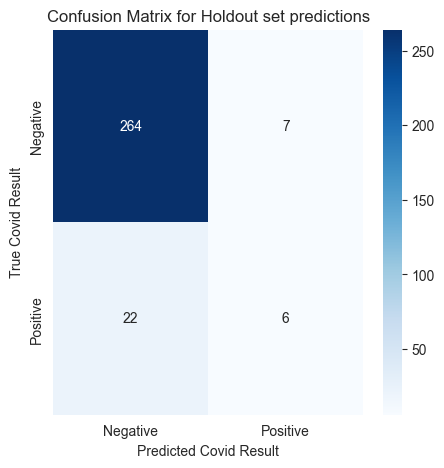

In [271]:
#Base model
xgb_base = XGBClassifier(random_state = 1, n_jobs = -1)
xgb_base.fit(df_predictor_train, df_classifier_train)
xgb_base_predictions = xgb_base.predict(df_predictor_test)
test_xgb_base_score = xgb_base.score(df_predictor_test, df_classifier_test)
test_xgb_base_f1 = f1_score(df_classifier_test,xgb_base_predictions, average='macro')
print(f'xgb_base score is \n{test_xgb_base_score}\n xgb_base f1 is \n{test_xgb_base_f1}')
cm = confusion_matrix(df_classifier_test, xgb_base_predictions)
plt.figure(figsize = (5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix for Holdout set predictions')
plt.xlabel('Predicted Covid Result')
plt.ylabel('True Covid Result')
plt.show()

The below cells set up a faster way to test multiple baseline models at once. In this case XGboost, Randomforest and BalancedRandomForest were used as they all handle sparse and imbalanced data well. They are run across 5 stratified K folds (SKF) of training and test data. SKF is useful as it splits all the input data into folds and allows use of cross validation by fitting and scoring models on each of these folds, then finding the mean of the folds F1 scores. (There are libraries that automatically perform cross validation, but in use they can all introduce major data leakage at the post processed stage. For consistency a 'brute force' cross validation method is created with nested for loops. this is computationally inefficient but for this data set it is comparable in compute time)

In [272]:
#uses a fitted model to predict on the test set and provide F1 and accuracy scores.
def model_predict(fitted_model, dfx_test, dfy_test):
    predictions = fitted_model.predict(dfx_test)
    score = fitted_model.score(dfx_test, dfy_test)
    f1 = f1_score(predictions, dfy_test, average = 'macro')
    model_name = fitted_model.__class__.__name__
    return predictions, score, f1, model_name

In [273]:
#Prints a graph showing accuracy and F1 scores of various models on a single test train split run
def compare_models(models, dfx_test, dfy_test):
    results = []
    for model in models:
        predictions, score, f1, model_name = model_predict(model, dfx_test, dfy_test)
        results.append({
            'Model': model_name,
            'Accuracy': score,
            'F1-Score': f1
        })
        print(f'{model_name} score is \n{score}\n{model_name} f1 is \n{f1}')
        #create confusion matrixes
        matrix = confusion_matrix(dfy_test, predictions)
        plt.figure(figsize = (4,4))
        plt.title(f'Confusion Matrix on Single Split for {model_name}')
        sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
        plt.xlabel('Predicted Covid Result')
        plt.ylabel('True Covid Result')
        plt.show()

    # build a melted df to plot results as comparison bar chart
    df_results = pd.DataFrame(results)
    df_plot = df_results.melt(id_vars='Model', var_name='Metric', value_name='Value')
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_plot, x='Model', y='Value', hue='Metric')
    plt.title('Single TT Split Model Performance Comparison')
    plt.ylim(0, 1.1) # keep axis locked at 0 - 1 so comparisons are easier
    plt.ylabel('Score')
    plt.grid(axis='y', linestyle='-')
    plt.show()

    return df_results

Model RandomForestClassifier cross val fold score is 
0.5130046607460488
Model XGBClassifier cross val fold score is 
0.6029158505758468
Model BalancedRandomForestClassifier cross val fold score is 
0.5783500412026845
RandomForestClassifier score is 
0.903010033444816
RandomForestClassifier f1 is 
0.5066848722762701


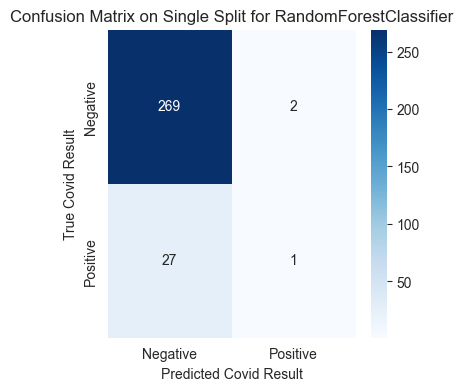

XGBClassifier score is 
0.903010033444816
XGBClassifier f1 is 
0.6203091474361782


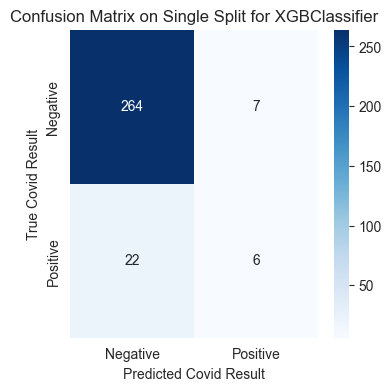

BalancedRandomForestClassifier score is 
0.6989966555183946
BalancedRandomForestClassifier f1 is 
0.5625243854857589


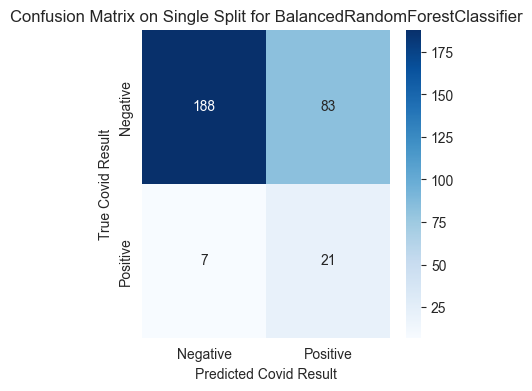

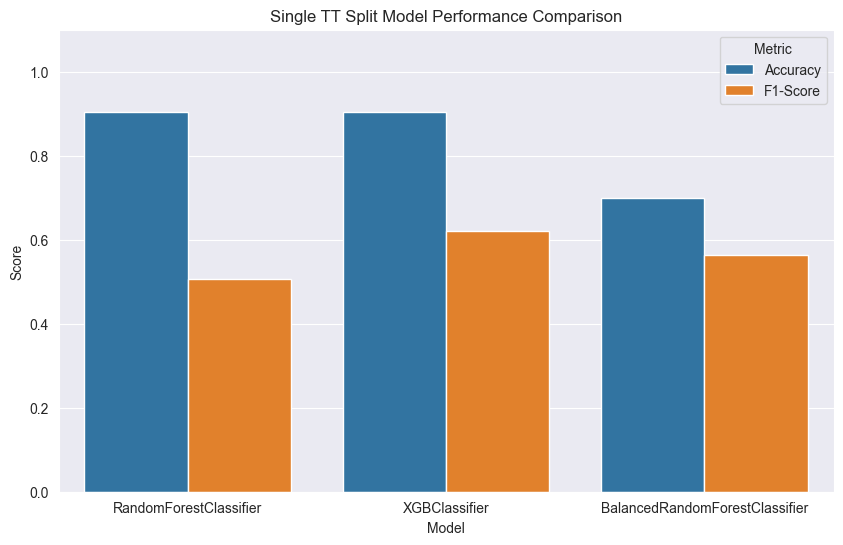

,Model,Accuracy,F1-Score
0,RandomForestClassifier,0.903010,0.506685
1,XGBClassifier,0.903010,0.620309
2,BalancedRandomForestClassifier,0.698997,0.562524


In [274]:
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 1)
results = {}
fitted_models = []
baseline_model_out = {}
unfitted_models = [
    RandomForestClassifier(),
    XGBClassifier(),
    BalancedRandomForestClassifier(),
    #KNeighborsClassifier(n_neighbors = 5) #requires nan handling, needs to be tested separately

]

for model in unfitted_models:
    model_name = model.__class__.__name__
    fold_scores = []
    for train_index, test_index in skf.split(df_predictors, df_classifiers):
        x_train, x_test = df_predictors.iloc[train_index].copy(), df_predictors.iloc[test_index].copy()
        y_train, y_test = df_classifiers.iloc[train_index].copy(), df_classifiers.iloc[test_index].copy()
        x_train, x_test, encoder = one_hot_encoder(x_train, x_test)
        model.fit(x_train, y_train)
        predictions = model.predict(x_test)
        fold_scores.append(f1_score(y_test, predictions, average = 'macro'))
    results[model_name] = np.mean(fold_scores)
    print(f'Model {model_name} cross val fold score is \n{results[model_name]}')

for unfitted_model in unfitted_models:
    #run_cross_val(unfitted_model, processed_dfx, processed_dfy)
    unfitted_model.fit(df_predictor_train, df_classifier_train)
    fitted_models.append(unfitted_model)
    baseline_model_out[unfitted_model.__class__.__name__] = unfitted_model
compare_models(fitted_models, df_predictor_test, df_classifier_test)

From the above graph and prints, it is clear that in the single test train split both XGB and RandomForest had the highest accuracy score of around 0.9. However, the F1 scores are more distributed, with XGB showing the highest single split F1 at 0.62. The cross validation scores however show a more representative insight into each models performance, with RandomForest showing a much lower F1 score than BalancedRandomForest and XGB. This is likely because there is no hyperparameter tuning, and XGB and BalancedRandomForestClassifiers are better at dealing with high class imbalance data. Once the processing steps are completed, each model will be revisited to see which gives the best F1 score and will therfore be used to predict the unseen dataset.

## Exploratory Data Analysis (EDA)
When first looking at a dataset it is imperative to carry out some forms of EDA. This ensures that the right kinds of processing are carried out to uncover the most impactful relationships and correlations. When loading in the dataset it was previously established that there is a significant class imbalance present, as well as a high percentage of NaN values, both of these will have to be handled going forward, but there are other insights to look at. The steps already looked at in the ingestion stage are:

* Class imbalance. Some common methods for testing model performance are not suitable. As part of the brief it is mentioned that the F1 score will be used to assess model performance from a marking perspective, as it already takes into account this issue of class imbalance. For this reason the F1 score will also be the primary performance criteria for this model.

* High percentage of NaN values. This is harder to deal with as there could be certain features that are only have results for patients who are more likely to have a positive COVID-19 assay and dropping columns that have high percentages of NaNs outright could lead to these features being absent and the model losing out on critical information. This is difficult to discern with no expertise in the area, and feature selection would be more robust if an expert could weight certain columns based on their value to the model.

### Correlation and Clustering
The next step is looking at a correlation heatmap to see if there are likely to be redundant columns, which can be used to inform feature reduction steps. To do so a correlation matrix can be formed, based on the spearman's rank. The correlation of the dataset will show if there are certain columns that have redundant features. This is useful as it simplifies the models and prevents potential double weighting of results, leading to a biased model. The data analysis steps will help inform the feature reduction steps further down the line.

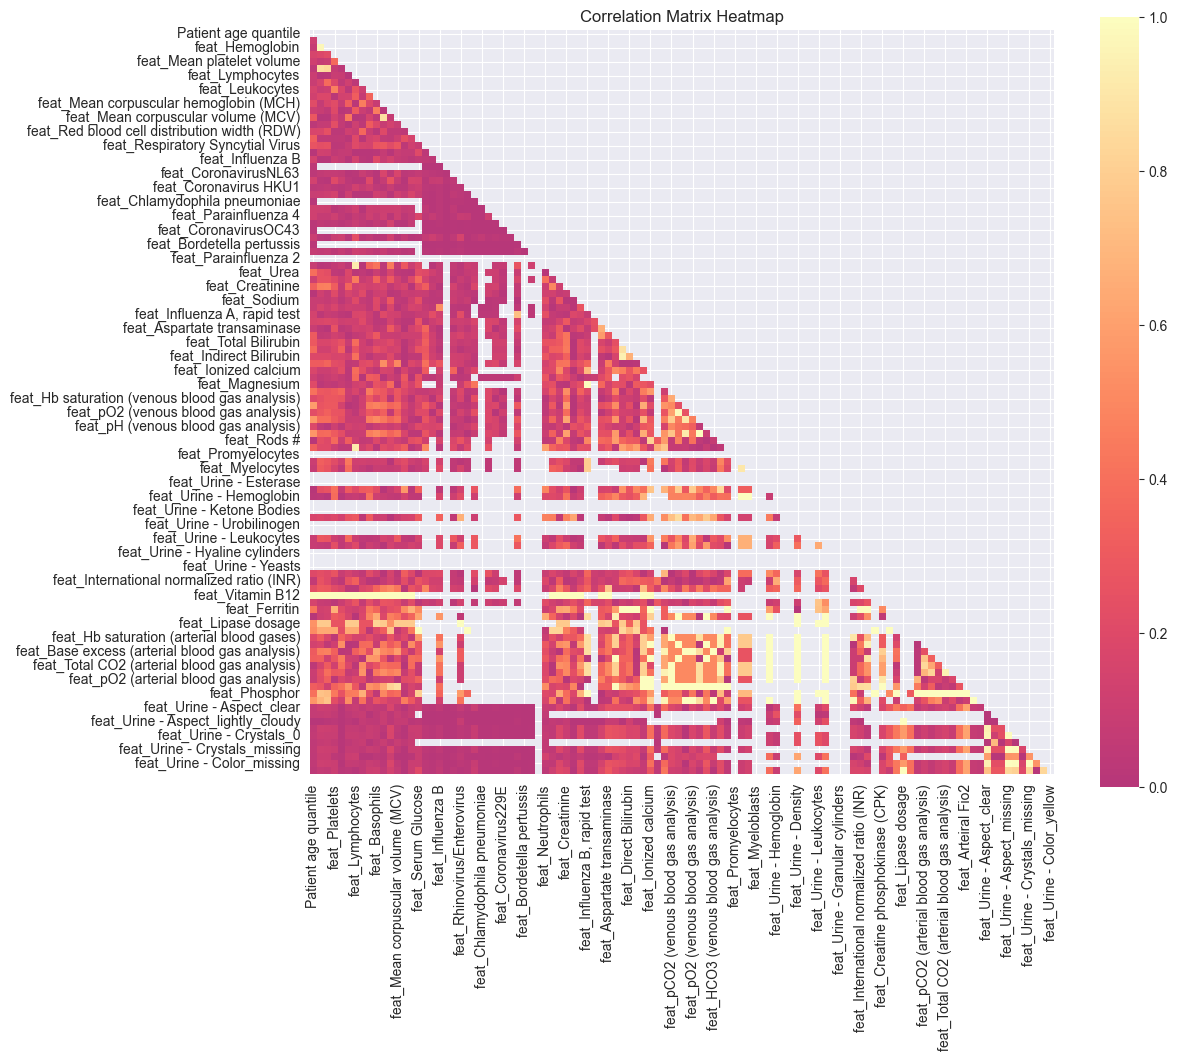

In [275]:
#Correlation matrix
corr_matrix = df_predictor_train.corr(method = 'spearman').abs()
heat_mask = np.triu(np.ones_like(corr_matrix, dtype = bool))
plt.figure(figsize = (12,10))
sns.heatmap(corr_matrix, mask = heat_mask, cmap = 'magma', vmin = 0, vmax = 1, center = 0, square = True)
plt.title('Correlation Matrix Heatmap')
plt.show()

The matrix above shows areas of high correlation around the blood gas analysis sections and parts of the urine analysis section. There are also many features with low correlations. Given the current number of features in the dataset, these results justify use of principal component analysis to carry out feature reduction. In addition to the heat map, a dendrogram can be plotted to show the hierarchical clusters within the data. This is used over k-means centroid based clustering as the data has highly variable densities and high dimensionality.
To refine this further and view the clusters that may be suggested in the dataset, a dendrogram can be drawn using the correlation matrix that was defined earlier. This is then converted to a distance matrix and the linkage between them is found using agglomerative clustering *(Nobel 2024)*. The ward clustering method was chosen for this application as it minimises the internal cluster variance making the clusters easier to see and tends to perform better in this use case vs other linkage methods *(Ferriea et al. 2009)*. This clustering will then show a representation that helps verify how many clusters is roughly expected from the upcoming PCA.

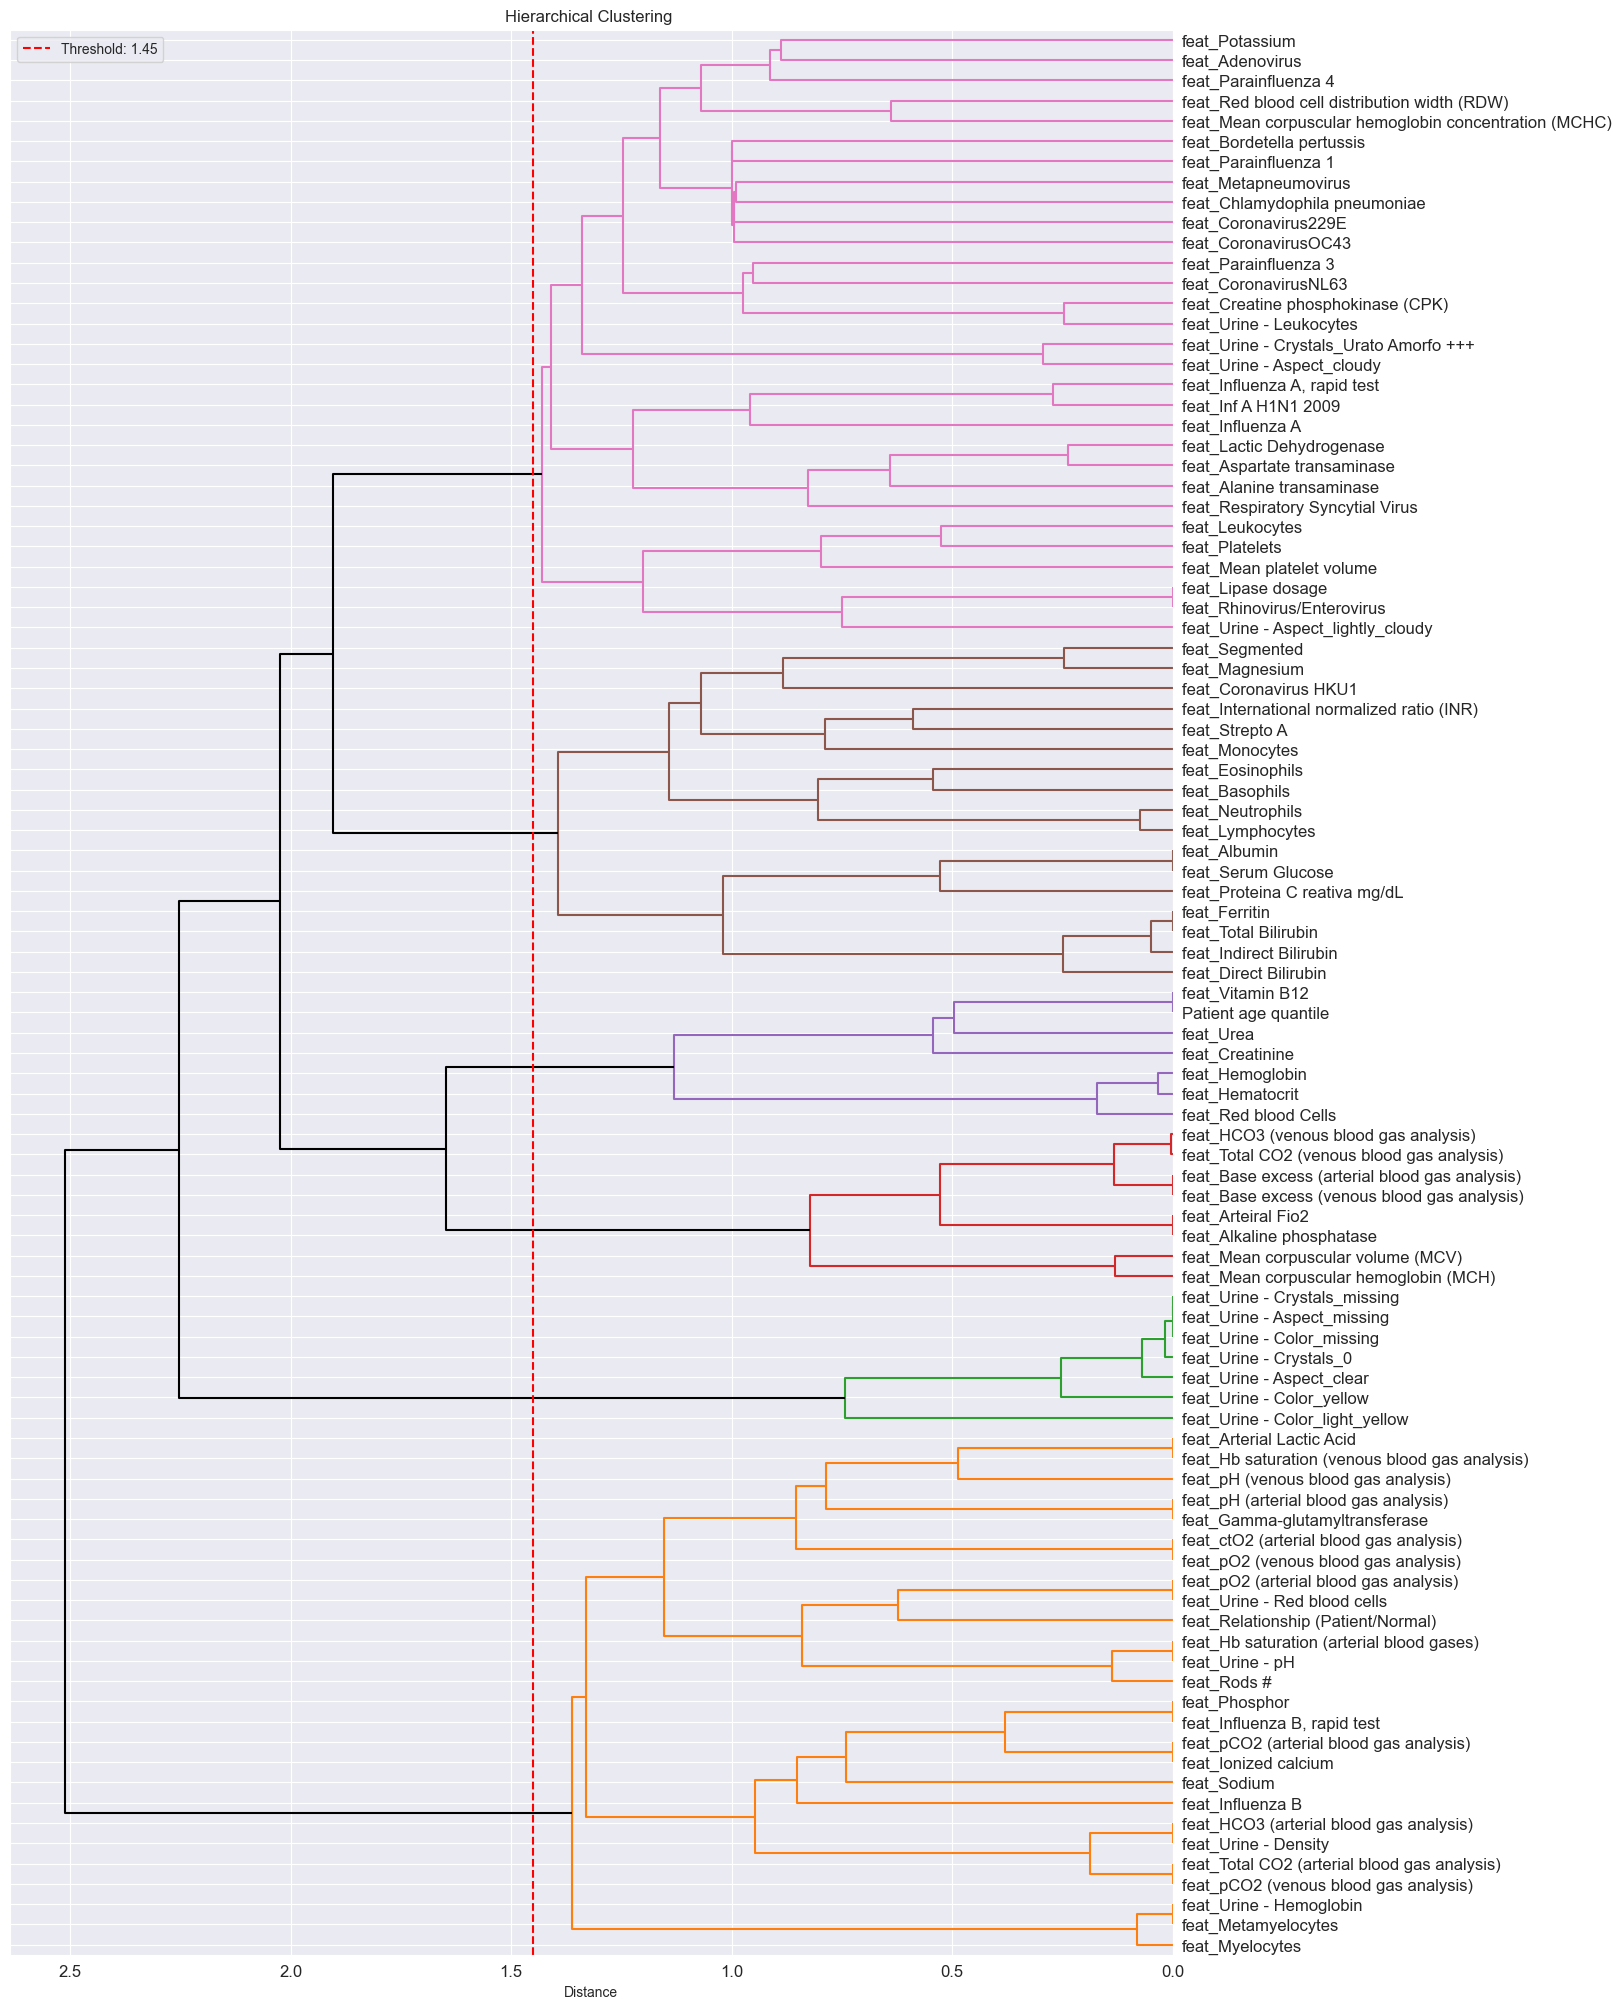

In [276]:
#methods will not work with NaN values.
no_nan_corr = corr_matrix.dropna(how = 'all', axis = 0).dropna(how = 'all', axis=1)
no_nan_corr.fillna(0, inplace = True)
dist_matrix = 1 - no_nan_corr.abs()
#squareform to cut off the duplicated triangle of data in the matrix like with the heatmap
condensed_dist = squareform(dist_matrix, checks = False)
clusters = hierarchy.linkage(condensed_dist, method = 'ward')
plt.figure(figsize=(15, 25))
threshold = 1.45

colour_cluster_dendrogram = hierarchy.dendrogram(
    clusters,
    labels = no_nan_corr.columns,
    orientation = 'left',
    color_threshold = threshold,
    above_threshold_color = 'black'
)

plt.axvline(x = threshold, color = 'red', linestyle = '--', label = f'Threshold: {threshold}')
plt.title('Hierarchical Clustering ', fontsize = 12)
plt.xlabel('Distance')
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.legend(loc = 'upper left')
plt.show()

The threshold in the above dendrogram plot was derived using the elbow method for hierarchical clustering. This is a heuristic method where the distance moved at each merge is plotted and the point where the gradient of the resulting plot changes the most is the point at which the threshold should be drawn. In this case, the elbow plot shows a suggested threshold of about 1.45, which is then used to create the above dendrogram and the resultant 6 suggested clusters.

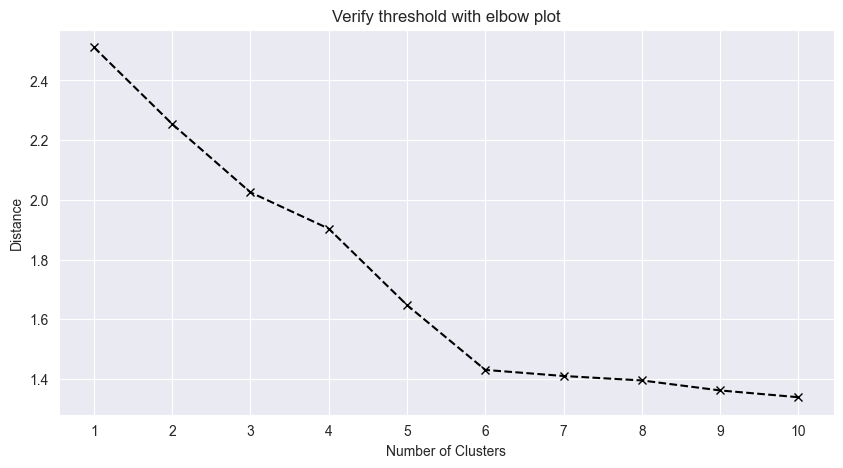

In [277]:
#find the distances of the last 10 merge operations
distances = clusters[-10:, 2]
#flip the distances around to plot the biggest jumps first
distances_rev = distances[::-1]
# make into nice to read x label.
x_labels = np.arange(1, len(distances) + 1)

plt.figure(figsize = (10, 5))
plt.plot(x_labels, distances_rev, marker = 'x', linestyle = '--', color = 'black')
plt.title('Verify threshold with elbow plot')
plt.xlabel('Number of Clusters')
plt.ylabel('Distance')
plt.xticks(x_labels)
plt.grid(True)
plt.show()

### Outlier Visualisation
Visualising outliers and distributions within the data will help inform the methods used to reduce skew and remove outliers. If outliers are present in data used to train models it can lead to less accurate models as they get mislead during the training process *(Brownlee, 2013)*. Using box plots can easily help visualise these. For each of the clusters identified in the correlation section, box plots can be created that show the outliers and distribution of each feature. This does exclude some columns from the df_predictor_training due to the NaN filtering that was carried out, but will give a good overall view of the data.

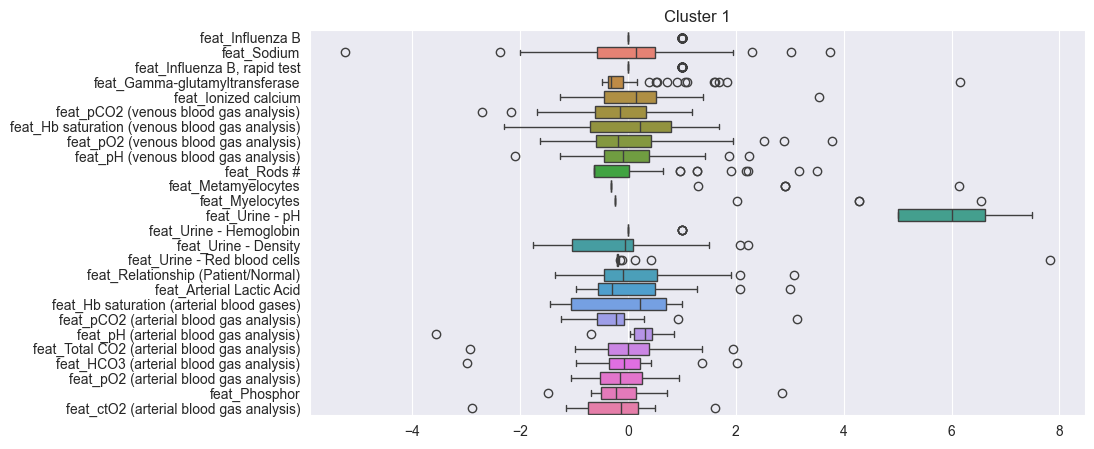

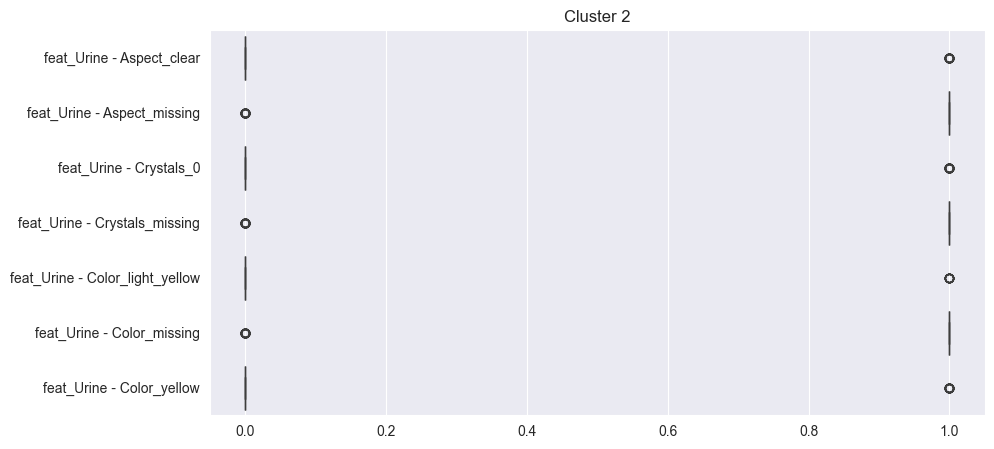

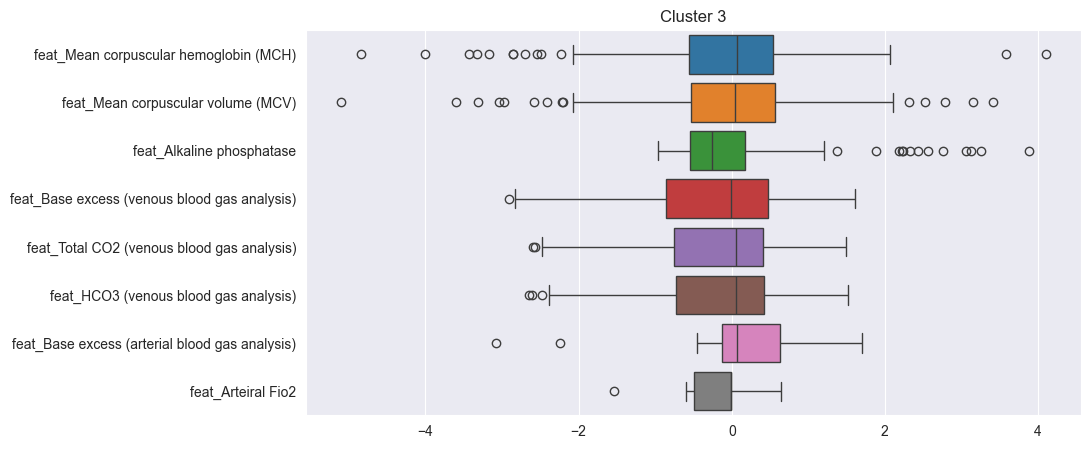

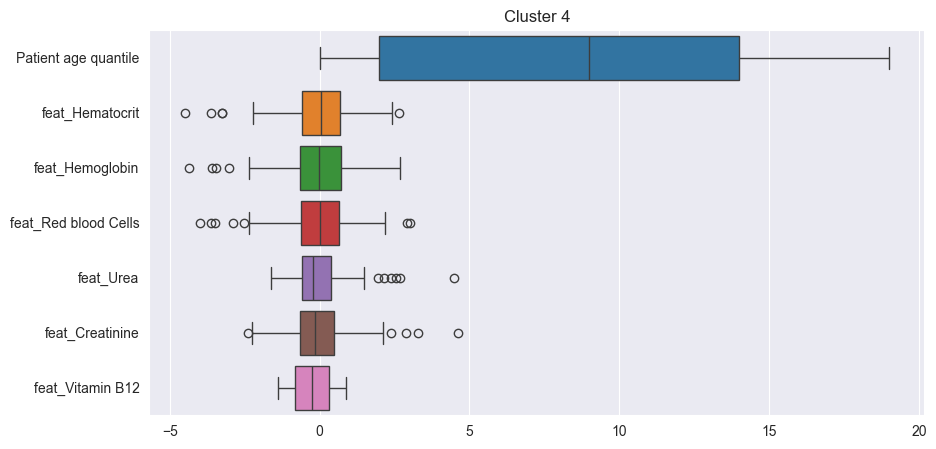

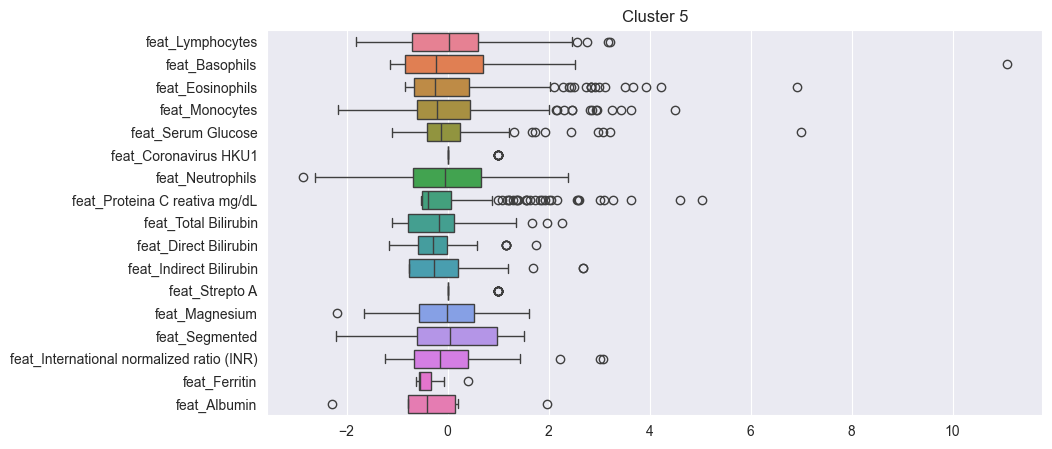

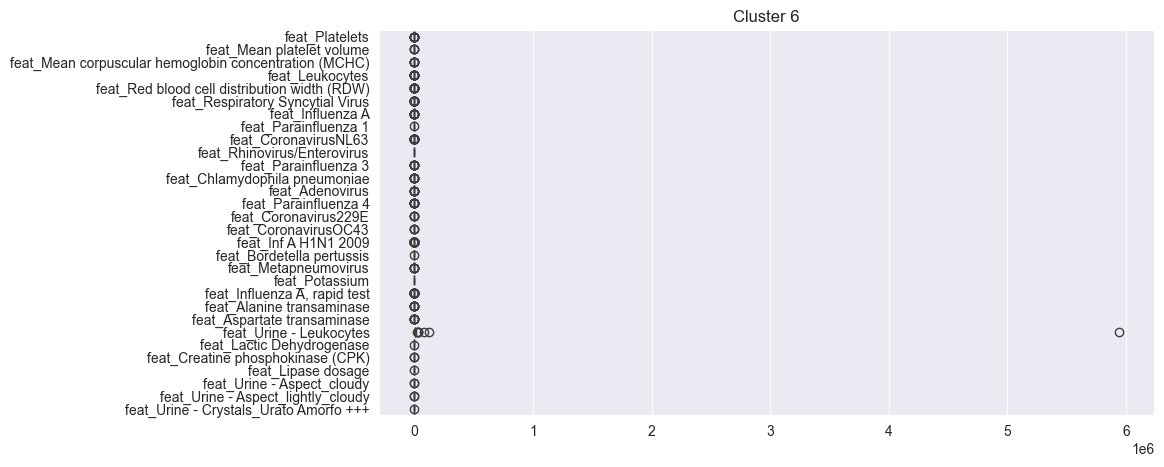

In [278]:
# create the clusters from the dendrogram and make a series matched with the column names.
cluster_features = fcluster(clusters, t = 1.45, criterion = 'distance')
cluster_cols = pd.Series(cluster_features, index = no_nan_corr.columns)
# go through each cluster, get the feature names and make a box plot of those features.
for i in range(1, 7):
    feats = cluster_cols[cluster_cols == i].index.tolist()
    plt.figure(figsize = (10, 5))
    plt.title(f'Cluster {i}', fontsize = 12)
    sns.boxplot(data = df_predictor_train[feats], orient = 'h')

When looking at the box plots, cluster 2 and cluster 6 stand out immediately, cluster 2 contains binary data with a heavy balance to one particular value. This makes the plots thin lines with a plot of outliers at the opposite side of the graph. This is not very helpful for drawing any conclusions aside from the imbalances in the feature set. Cluster 6 shows an extreme outlier for the urine_leukocytes feature. This makes the box plot hard to understand as all the other features get squashed down due to the extreme scaling as a result of the outlier. This is still useful information as it identifies this feature as being problematic. This is particularly interesting as the data is supposedly pre normalised to a mean of 0 and 1 standard distribution. This kind of result would indicate use of a power transformer such as Yeo-Johnson, which performs scaling and skew in the dataset as part of a single transformation, while allowing for transformations on both positive and negative skews, which the plots suggest would be present in the dataset.

### Missingness
As part of the ingestion of the data, columns and rows that were all NaN or had 0 variance were removed. However, it is easy to see from the head of df_all that there are still a high number of missing values left in the dataset. Columns with high numbers of missing values could lead to poor quality training data with a reduction in statistical power or the introduction of bias in the model predictions. for the model or potentially bias it. In most cases, removal of columns with high percentages of missing data is a good way to handle this issue but analysis of the 'missingness' of the dataset should be carried out to determine the best approach. The aim of missing data analysis is to help try and determine the mechanism of the missing data. These mechanisms describe the relationships between missing data points and are known as:
* Missing completely at random (MCAR) where missingness is unrelated to all other features and to the classification, this data usually doesn't influence bias in a model, but it can reduce statistical power, it should be handled with multiple imputation methods to limit the reduction in power.
* Missing at random (MAR) where missingness is related to other features but not related to the classification. This cannot be tested for but can also be handled by multiple imputation methods.
* Missing not at random (MNAR) where missingness is directly related to the classification. This cannot be tested for and introduces bias to the model.
*(Geiser, 2025)*.

In this dataset it is not likely to have the MNAR mechanism, as there is a classification result for every entry in the dataset. Utilising plots of missing data can help construct an apporach to handling the missing data.

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102,
  103,
  104,
  105],
 [Text(0, 0, 'Patient age quantile'),
  Text(1, 0, 'feat_Hematocrit'),
  Text(2, 0, 'feat_Hemoglobin'),
  Text(3, 0, 'feat_Platelets'),
  Text(4, 0, 'feat_Mean platelet volume'),
  Text(5, 0, 'feat_Red blood Cells'),
  Text(6, 0, 'feat_Lymphocytes'),
  Text(7, 0, 'feat_Mean corpuscular hemoglobin concentration (MCHC)'),
  Text(8, 0, 'feat_Leukocytes'),
  Text(9, 0,

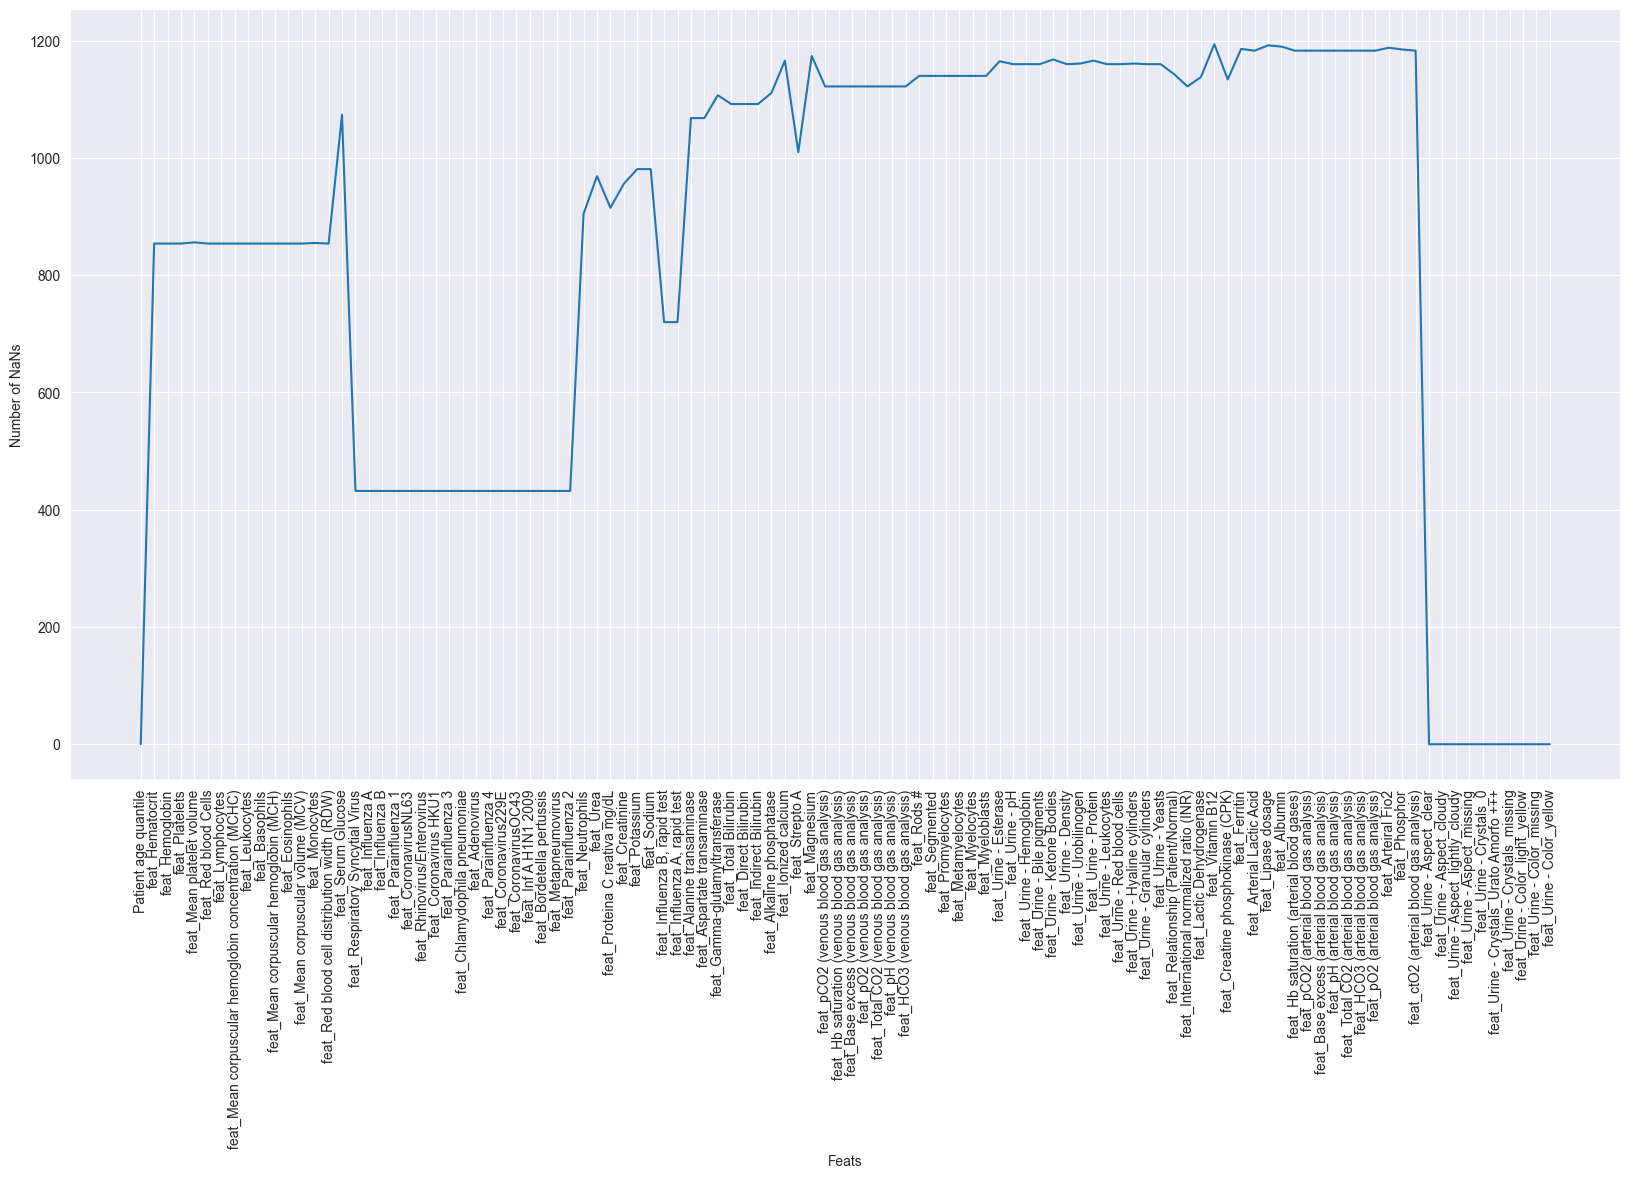

In [279]:
# Create a simple plot of missing values per feature
missing_per_column = df_predictor_train.isnull().sum(axis=0)
#Plot them on a simple graph
plt.figure(figsize = (20, 10))
plt.grid(True)
plt.plot(missing_per_column)
plt.xlabel('Feats')
plt.ylabel('Number of NaNs')
plt.xticks(rotation = 90)

<Axes: >

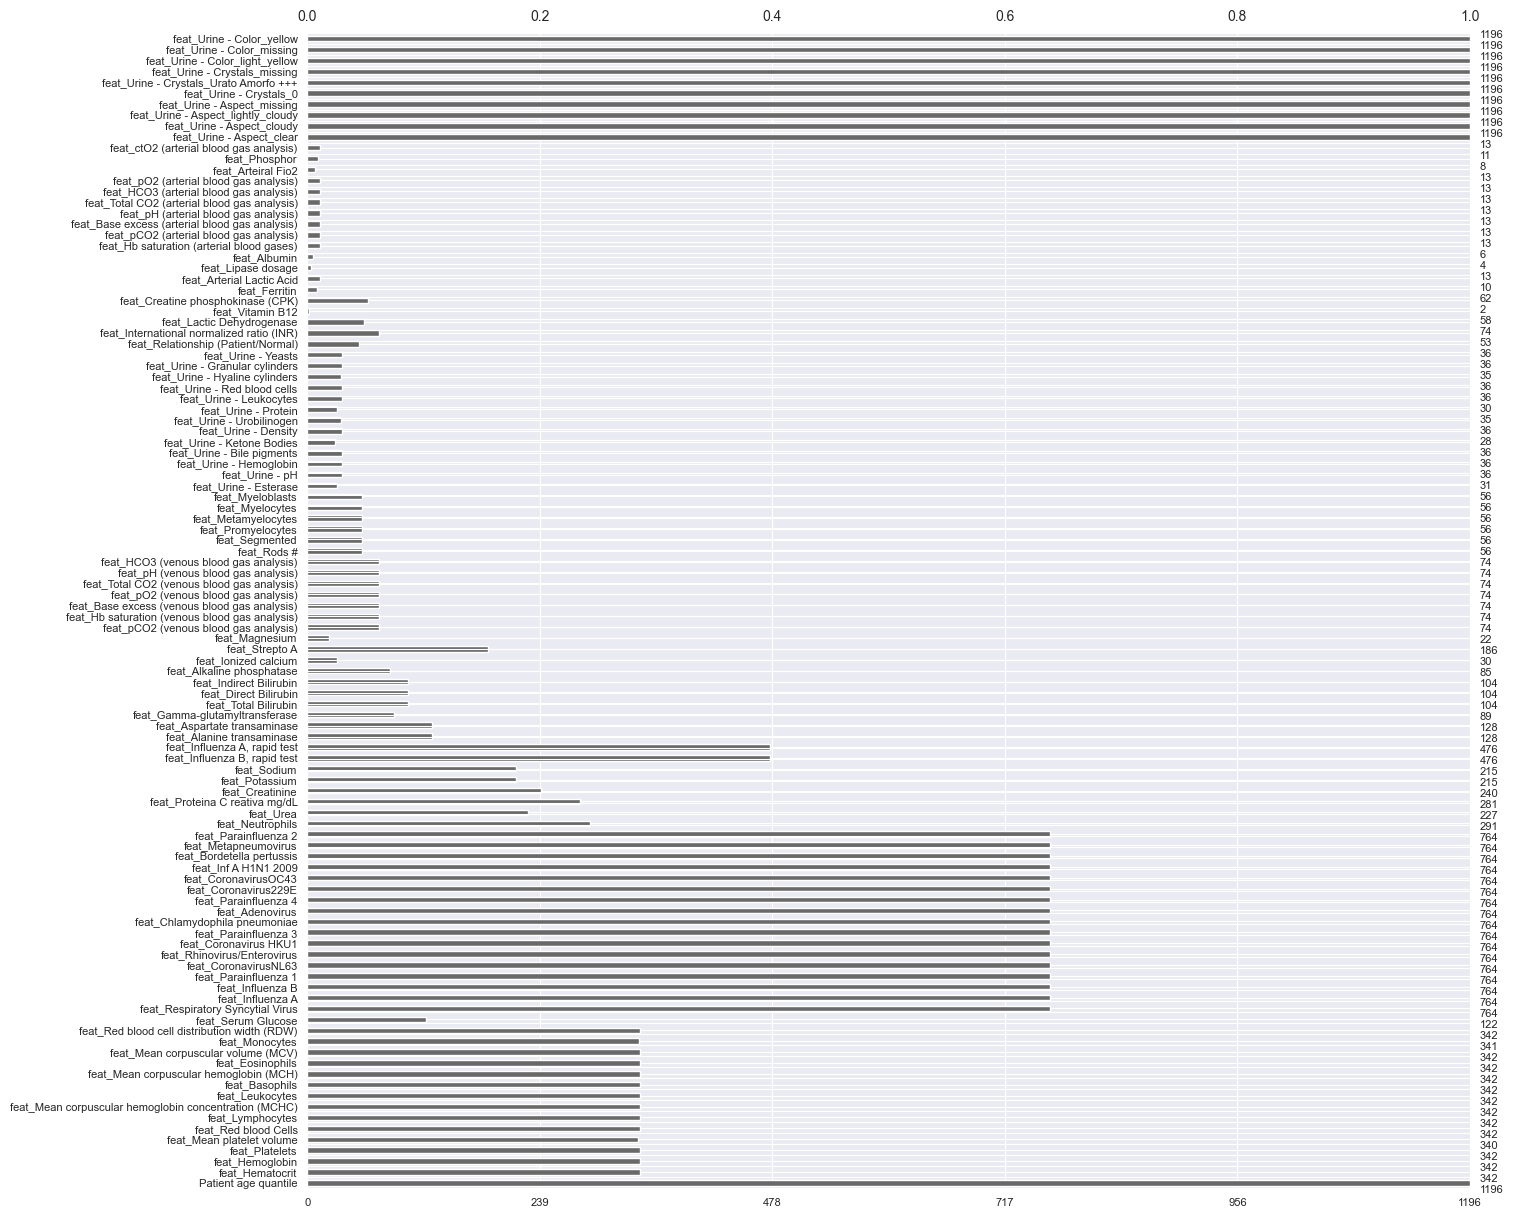

In [280]:
#alternate plots using msno
msno.bar(df_predictor_train, figsize=(15 ,15), fontsize=8)

The 2 plots above show that there is a high variance to the amount of values missing per feature. Some features have all data points present, but these are mostly the extra columns that were created by One-Hot encoding when the categorical data was dealt with. There are also features that are missing almost all the data points such as vitamin b12. Next a plot of the correlation of missingness for each column can show if features are more or less likely to be present based on the presence of a different feature.

<Axes: >

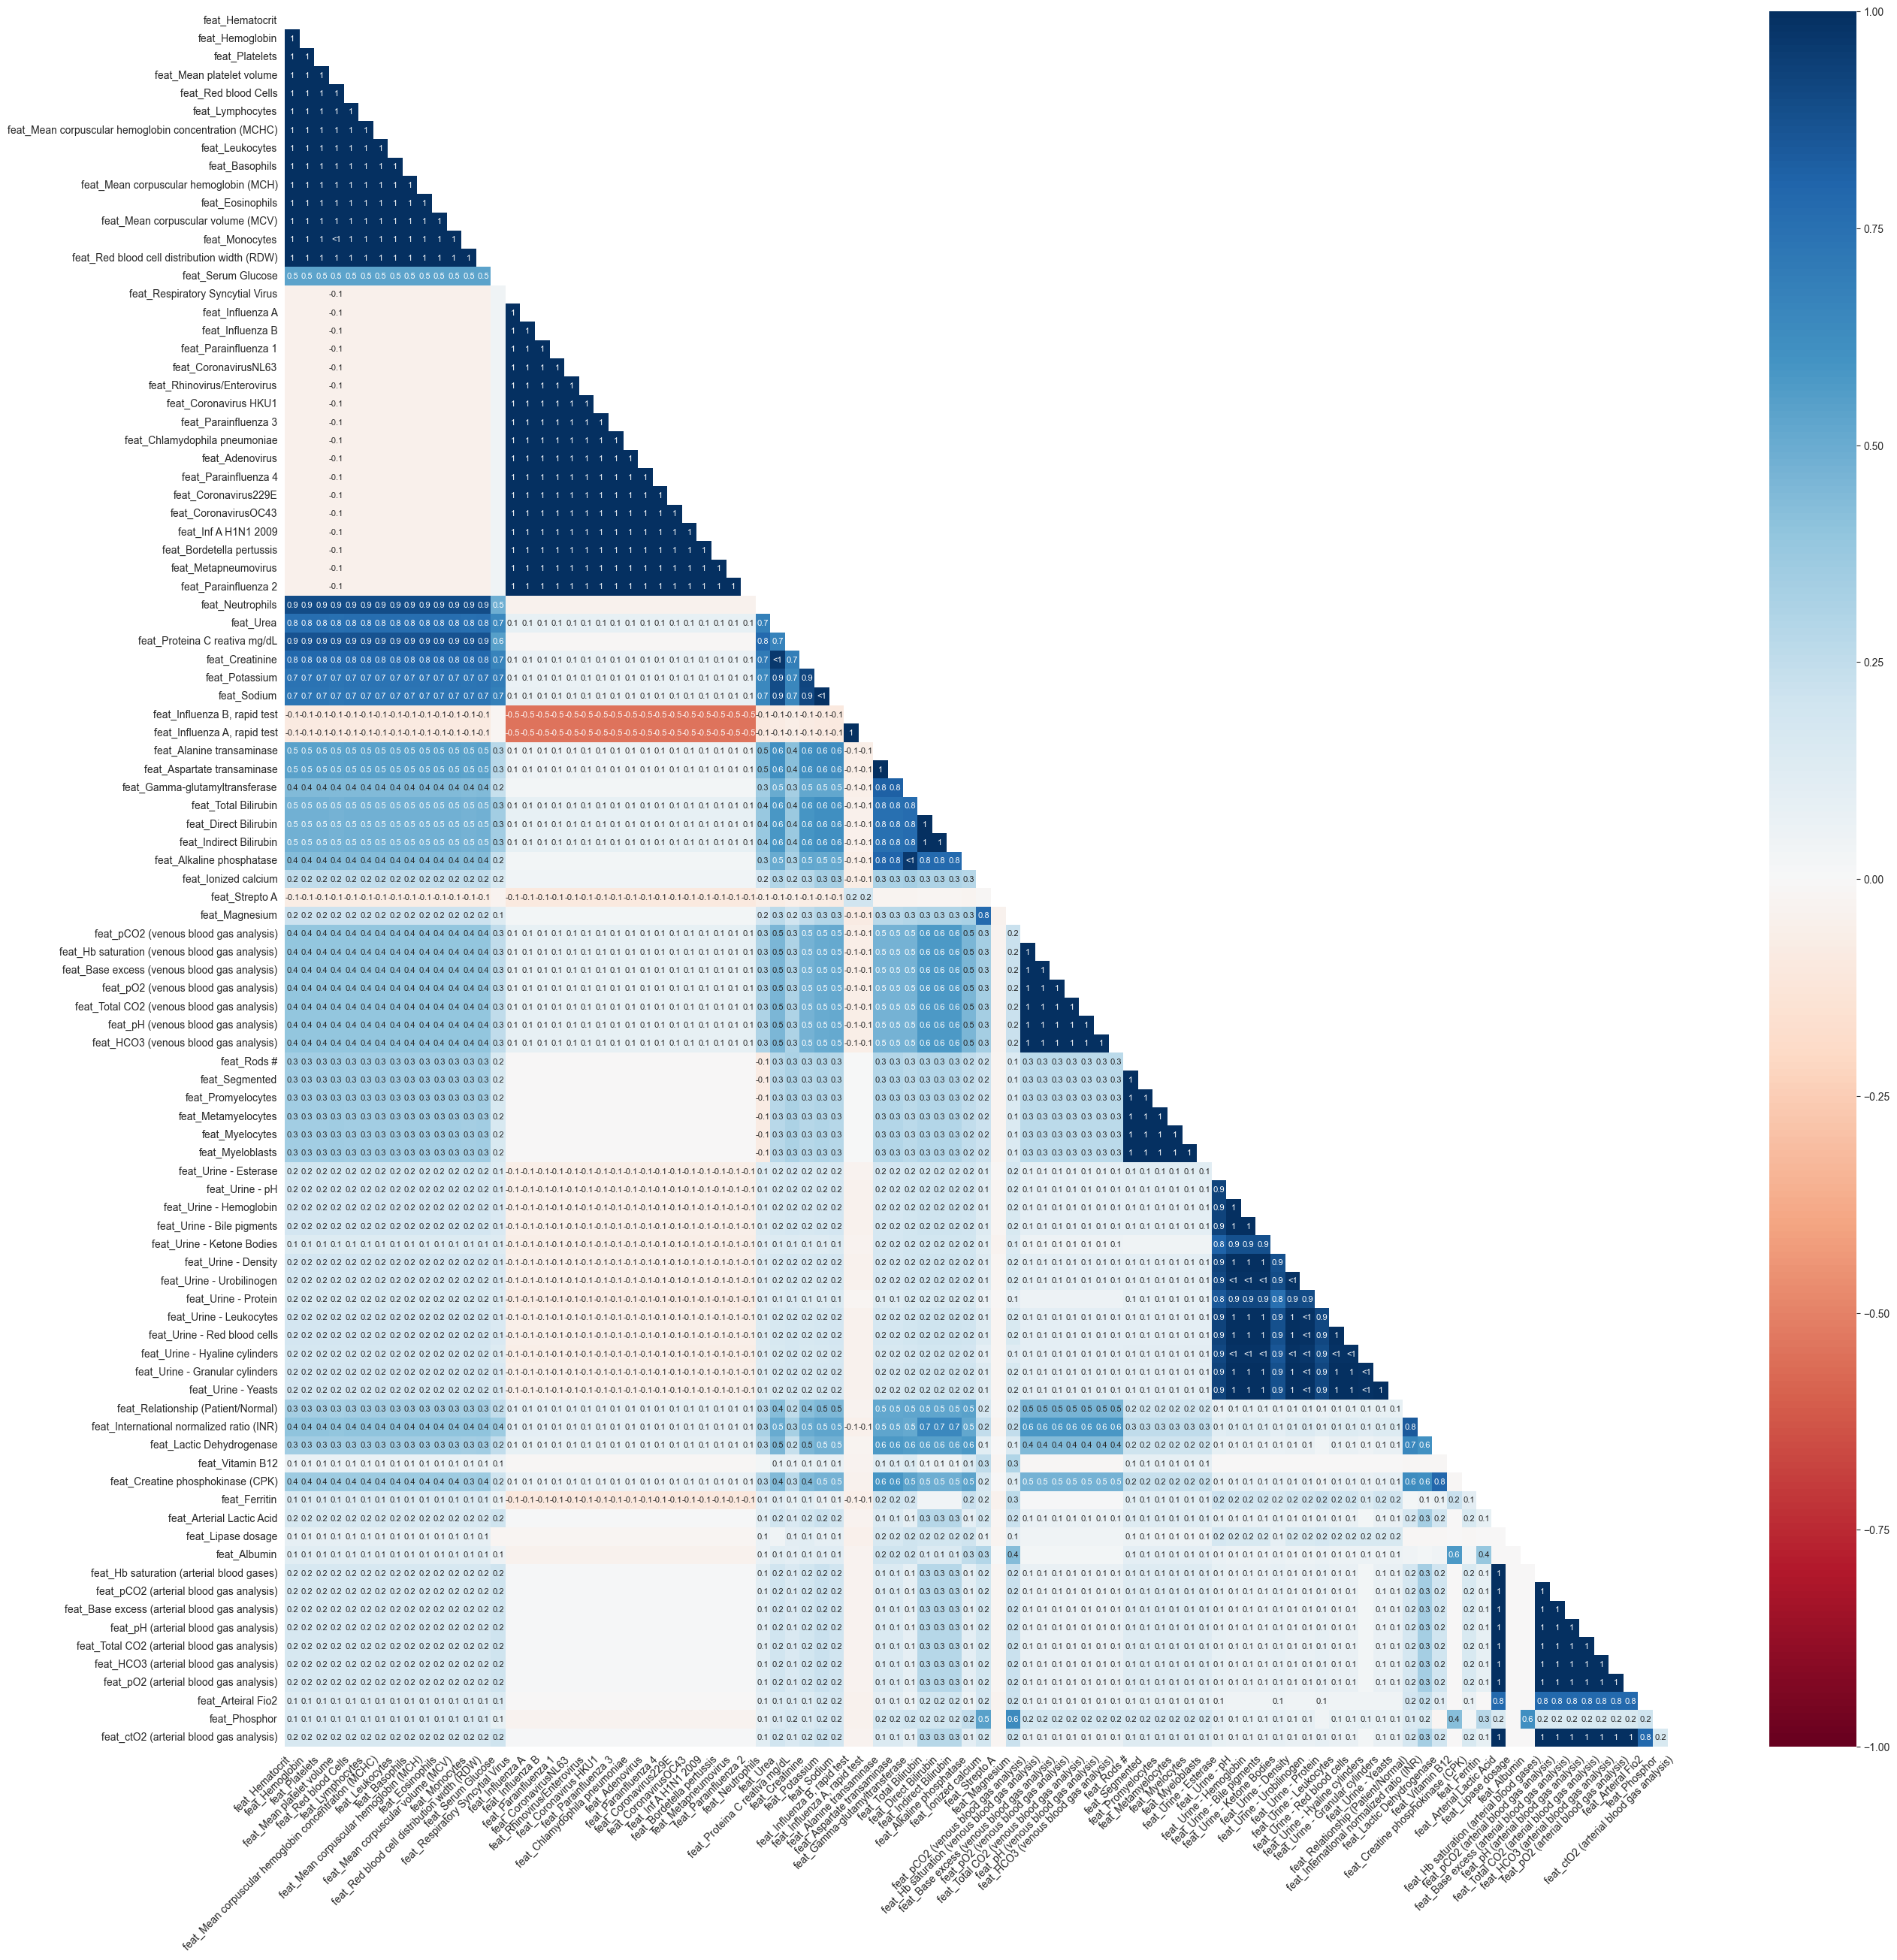

In [281]:
msno.heatmap(df_predictor_train, figsize= (30 ,30), fontsize = 10)

The heatmap shows that there is a high correlation (lighter blues) between the presence of a lot of features in the dataset, meaning that they are more likely to be MAR rather than MCAR in those cases.
It is easy to see on the graph that there are a vast number of columns missing a high proportion of their data. Little's MCAR test could be used on the dataset to determine if there is a case for MCAR in the data, but given the high correlations seen in the heatmap it is highly likely that the data is mostly MAR and given that the handling of both MCAR and MAR data can be done via multiple imputation it is more time and computationally efficient to skip further testing at this point and continue forward with the data processing.

## Processing
This section contains processing steps that will further prepare the data for use in training the classifier models. It will cover the following steps:
* Dealing with NaN values
* Dealing with outliers and skew
* Performing feature reduction via PCA
* Dealing with class imbalance

Firstly as identified in the EDA there is an issue of missing data points that are of the MAR mechanism. Outright dropping high NaN columns will not be the best way to deal with this as the loss of statistical power will be too great. However, columns with over 97% missing data are likely to be introducing more noise than statistical power. So they should be included in listwise deletion over the dataset as using them in imputation could cause problems.

In [282]:
# Check shapes pre drop:
print(f'Training shape is: {df_predictor_train.shape}\nTesting shape is: {df_predictor_test.shape}')

def missingness_thresholder(df_train,df_test, threshold):
    df_train.dropna(axis = 1, inplace=True, thresh = int(threshold * len(df_train)))
    keep_cols = df_train.columns
    df_test.drop(inplace = True, columns = df_test.columns.difference(keep_cols))
    return df_train, df_test, keep_cols

df_predictor_train, df_predictor_test, threshold_keep_cols = missingness_thresholder(df_predictor_train, df_predictor_test, 0.05)
#check how many columns are left post drop
print(f'The current shape of the data after dropping the columns is: \n Training: {df_predictor_train.shape}\nTesting: {df_predictor_test.shape}')

Training shape is: (1196, 106)
Testing shape is: (299, 106)
The current shape of the data after dropping the columns is: 
 Training: (1196, 68)
Testing: (299, 68)


The next step is to handle the rest of the NaN values via imputation. This is an algorithm that 'guesses' the most likely entry for a missing data point based on the other data in the dataset. Simple imputation could be in the form of replacing the missing values with the mean or median value for the column, but given the amount of missing values that still exist this would definitely bias the training of any models. The best case for this dataset is to use a multiple imputation method such as Multiple Imputation by Chained Equations (MICE). This will carry out a simple imputation initially and then iterate further imputations via regression *(Raf. 2024)*. This can be further augmented with regression trees to improve the imputation process, however during testing, the additional regressor proved to be ineffective in this case. With imputation the initial method of median is most often chosen as this takes into account any outlier data points, rather than allowing for the data to be skewed with multiple imputed means that were calculated with a huge outlier in the feature - such as the ones seen in the Leukocytes columns in the EDA box plots.

Iterative imputation


C:\Users\Jess\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67],
 [Text(0, 0, 'Patient age quantile'),
  Text(1, 0, 'feat_Hematocrit'),
  Text(2, 0, 'feat_Hemoglobin'),
  Text(3, 0, 'feat_Platelets'),
  Text(4, 0, 'feat_Mean platelet volume'),
  Text(5, 0, 'feat_Red blood Cells'),
  Text(6, 0, 'feat_Lymphocytes'),
  Text(7, 0, 'feat_Mean corpuscular hemoglobin concentration (MCHC)'),
  Text(8, 0, 'feat_Leukocytes'),
  Text(9, 0, 'feat_Basophils'),
  Text(10, 0, 'feat_Mean corpuscular hemoglobin (MCH)'),
  Text(11, 0, 'feat_Eosinophils'),
  Text(12, 0, 'feat_Mean corpuscular volume (MCV)'),
  Text(13, 0, 'feat_Monocytes'),
  Text(14, 0, 'feat_Red blood cell d

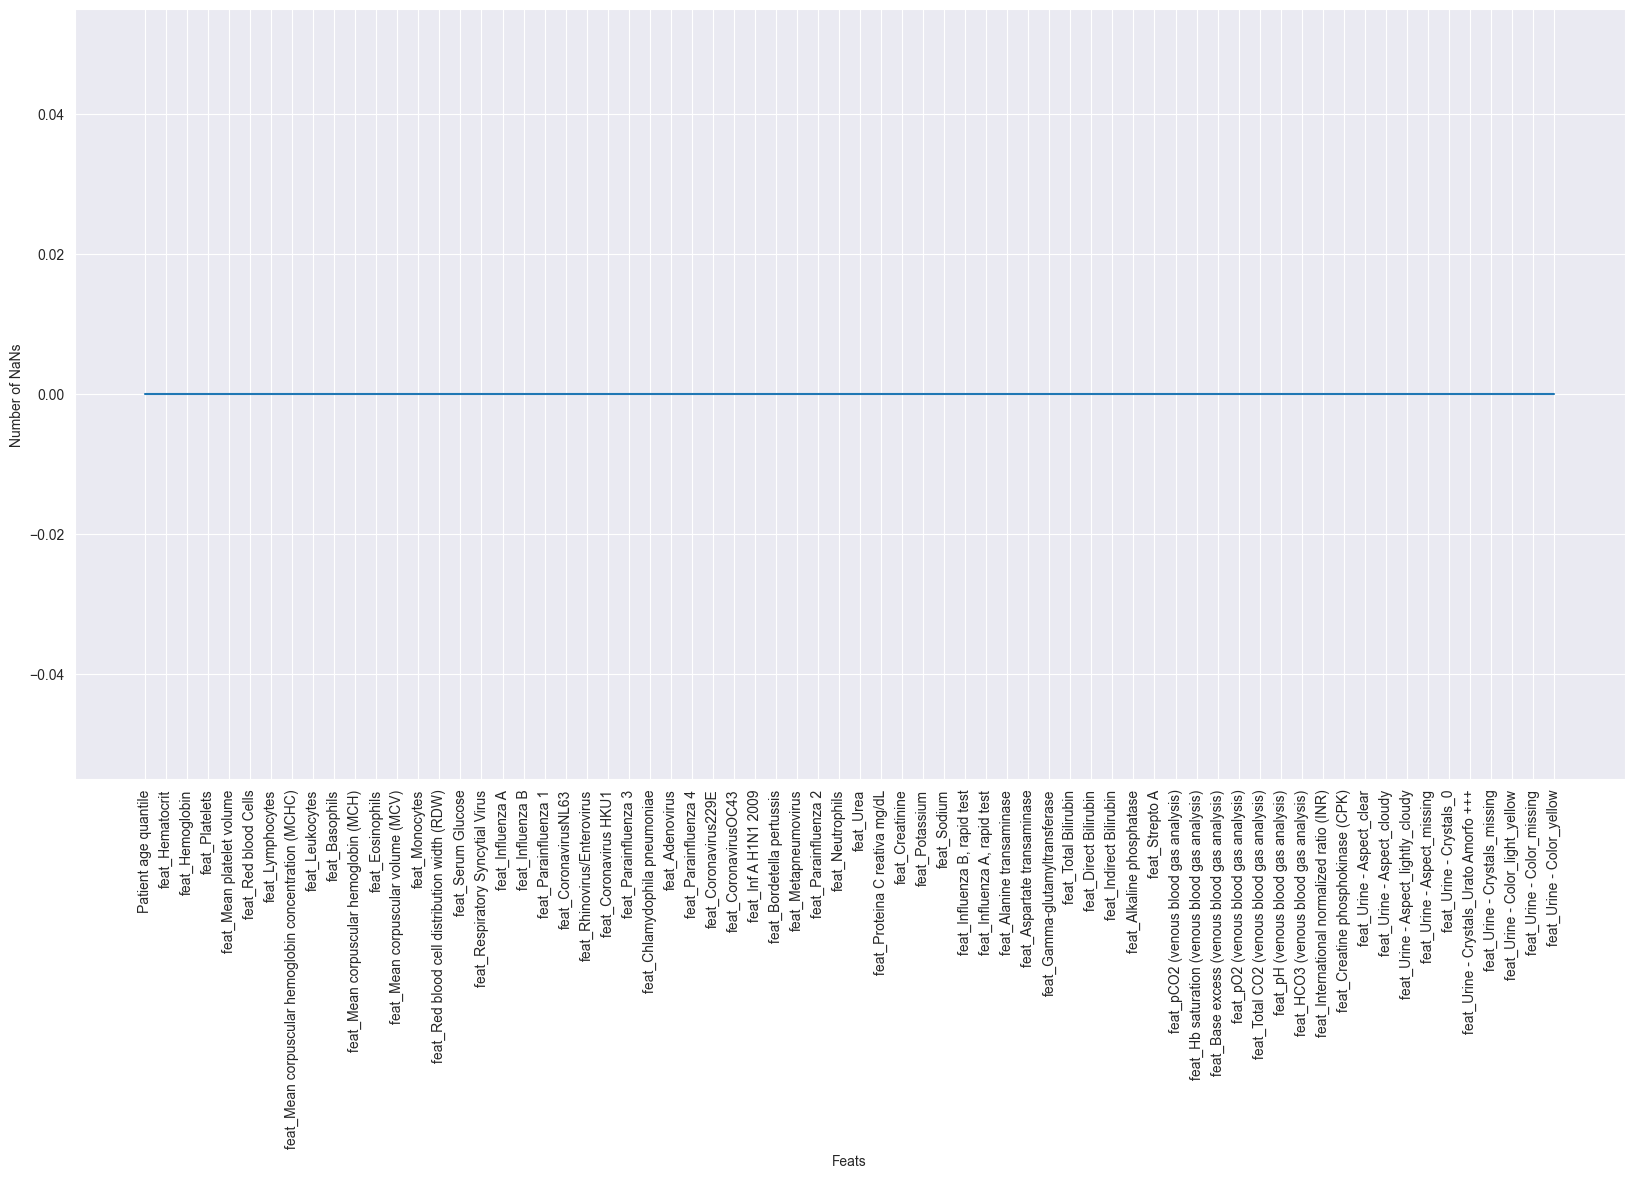

In [283]:
# Imputer function that allows for multiple imputing types to enable faster testing
def missingness_imputer(df_train,df_test, imputer_type = None, imputer_strategy = None):
    boolean_cols = df_train.select_dtypes(include = 'boolean').columns
    if imputer_type == 'iterative':
        print('Iterative imputation')
        imputer = IterativeImputer(max_iter = 50, random_state = 1, initial_strategy = imputer_strategy)
        imputer.set_output(transform = "pandas")
        imputer.fit(df_train)
        df_train_imputed = imputer.transform(df_train)
        df_test_imputed = imputer.transform(df_test)
    elif imputer_type == 'simple':
        print('Simple imputation')
        imputer = SimpleImputer(strategy = imputer_strategy)
        imputer.set_output(transform = "pandas")
        imputer.fit(df_train)
        df_train_imputed = imputer.transform(df_train)
        df_test_imputed = imputer.transform(df_test)
    else:
        print('Unknown imputation strategy, default to fillNa 0')
        imputer = None
        df_train = df_train.astype('float64')
        df_test = df_test.astype('float64')
        df_train.fillna(value = 0, inplace = True)
        df_test.fillna(value = 0, inplace = True)
        return df_train, df_test
    df_train_imputed[boolean_cols] = df_train_imputed[boolean_cols].astype(bool)
    df_test_imputed[boolean_cols] = df_test_imputed[boolean_cols].astype(bool)
    return df_train_imputed, df_test_imputed, imputer, boolean_cols

df_predictor_train, df_predictor_test, missing_imputer, boolean_cols = missingness_imputer(df_predictor_train, df_predictor_test, imputer_type = 'iterative', imputer_strategy = 'median')

#added retroactively after initial model runs. used to create a model that skips skew and PCA steps.
df_special_train = df_predictor_train.copy()
df_special_test = df_predictor_test.copy()
#confirm no missing values
missing_per_column = df_predictor_train.isnull().sum(axis=0)
plt.figure(figsize = (20, 10))
plt.grid(True)
plt.plot(missing_per_column)
plt.xlabel('Feats')
plt.ylabel('Number of NaNs')
plt.xticks(rotation = 90)

### Outliers & Skew
Having high skew or many outliers in the dataset will impact the ability of a model trained on it to reliably predict classification. A data set with low skew would follow a Gaussian distribution (also known as a normal distribution), forming a neat bell curve of results when plotted. Statistically almost all the data (95% of all points) in a Gaussian distribution are within 2 standard deviations from the mean *(Kaneko et al., 2008)*. The curve for a Gaussian distribution exhibits symetry around its median value, whereas skewed distributions make it much harder to distinguish where symetry occurs. Skew can be positive or negative, depending on which side of the curve is shifted along the x-axis. A positive skew shows a long tail that extends to the right hand side of the distribution curve. It has a mean greater than the mode and the median. Negatively skewed data is the opposite, with the tail to the left and the mean less than the mode and median. *(Sharma, R. 2022).*

As part of the EDA, the cluster box plots showed a potential for high positive skew as well as some extreme outliers. There was also a much smaller amount of negative skew present for some plots. To confirm this a distribution histogram can be plotted. The histogram needs to exlcude boolean values as the binary nature of these columns doesn't work with skew calculations or transformations.

<Axes: ylabel='Count'>

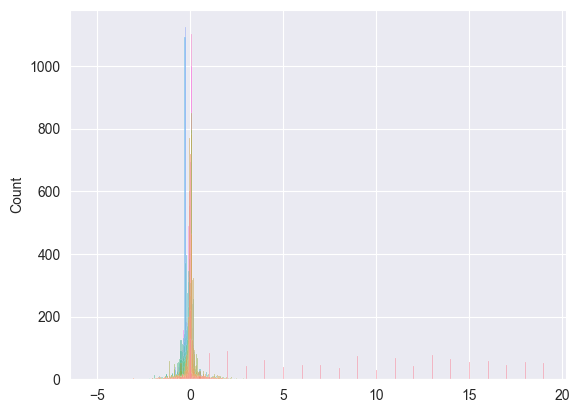

In [284]:
sns.histplot(data=df_predictor_train.select_dtypes(exclude = ['boolean']), legend = False)

The histogram above shows most columns following a normal distribution, which is to be expected as the dataset came pre-standardised to a mean of 0 and a unit standard deviation. However there is still a large right tail, showing the skew of the data set to be largely positive. Investigating this further by looking at the calculated skew values for each feature below shows how severely some columns are skewed.

Patient age quantile                                      0.070154
feat_Hematocrit                                          -1.226052
feat_Hemoglobin                                          -1.320304
feat_Platelets                                            3.774813
feat_Mean platelet volume                                 0.790533
feat_Red blood Cells                                     -0.496920
feat_Lymphocytes                                          0.300450
feat_Mean corpuscular hemoglobin concentration (MCHC)    -0.633181
feat_Leukocytes                                           1.862841
feat_Basophils                                            6.284617
feat_Mean corpuscular hemoglobin (MCH)                   -1.616166
feat_Eosinophils                                          3.656618
feat_Mean corpuscular volume (MCV)                       -1.425446
feat_Monocytes                                            1.756001
feat_Red blood cell distribution width (RDW)              4.09

Text(0, 0.5, 'Frequency')

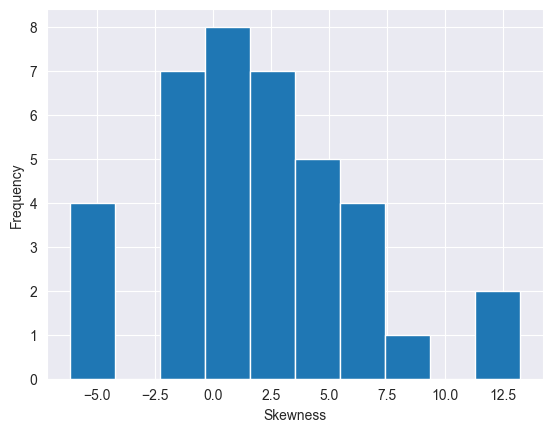

In [285]:
#check the skewness of the dataframe
skew = df_predictor_train.select_dtypes(exclude = ['boolean']).skew(numeric_only=True)
print(skew)
plt.hist(skew,10)
plt.xlabel('Skewness')
plt.ylabel('Frequency')

High skew columns are likely to introduce bias to the model, where there is already heavy class imbalance that could cause issues also. Therefore, these extremely skewed columns should be dropped. However, that alone is not enough, the data is still heavily positive skewed even with these columns removed. To handle this the data can be transformed to stabilise its variance. There are multiple methods available to handle this, such as logarithmic transformation or Box-Cox transformations. However, both of these methods cannot handle negative skew values at all and as there is a small amount of negative skew values in the dataset, it would not be appropriate to apply them here. Instead, the transformation will be handled by a Yeo-Johnson transformation, as this can handle both positive and negative skew values by adapting the Box-Cox transform formula. *(Image below: Strahl, 2018)*

<img src = "https://miro.medium.com/v2/resize:fit:1100/format:webp/1*hRbS-ES8lIdPzxaerKr4tg.png" alt = "image of yeo-johnson formula"/>

Yeo-Johnson transformation is part of the power transform library from Scikit. It tries to seek an optimal parameter to apply a transformation to a variable and bring it closer to a Gaussian distribution. This parameter denotes the kind of transform that would be carried out. For example if the best parameter is 0.0 then a logarithmic transform will be applied *(Brownlee, 2020). Yeo-Johnson transformations also scale and normalise the data, there is not expected to be a large resultant change from this as the data was provided scaled already.

Properties of a Yeo-Johnson Transform *(from Geeks For Geeks. 2025)*
* Continuity and Smoothness: The function is continuous and differentiable with respect to both 𝑦 and 𝜆.
* Reversible: The transformation is invertible, allowing you to recover the original data.
* Parameter Optimization: The optimal 𝜆 can be estimated from data using maximum likelihood or other methods.
* Normalizing Effect: Helps in transforming skewed data into approximately Gaussian distributions.

Patient age quantile                                    -0.260517
feat_Hematocrit                                          0.077168
feat_Hemoglobin                                          0.127133
feat_Platelets                                           0.096656
feat_Mean platelet volume                               -0.161019
feat_Red blood Cells                                    -0.127255
feat_Lymphocytes                                         0.191801
feat_Mean corpuscular hemoglobin concentration (MCHC)    0.135711
feat_Leukocytes                                         -0.165799
feat_Basophils                                          -0.264150
feat_Mean corpuscular hemoglobin (MCH)                   0.646610
feat_Eosinophils                                        -0.175715
feat_Mean corpuscular volume (MCV)                       0.410775
feat_Monocytes                                          -0.258728
feat_Red blood cell distribution width (RDW)            -0.387539
feat_Serum

(array([ 1.,  3.,  3.,  7., 12.,  6.,  2.,  1.,  1.,  2.]),
 array([-2.11498993, -1.68084089, -1.24669185, -0.81254281, -0.37839377,
         0.05575526,  0.4899043 ,  0.92405334,  1.35820238,  1.79235142,
         2.22650046]),
 <BarContainer object of 10 artists>)

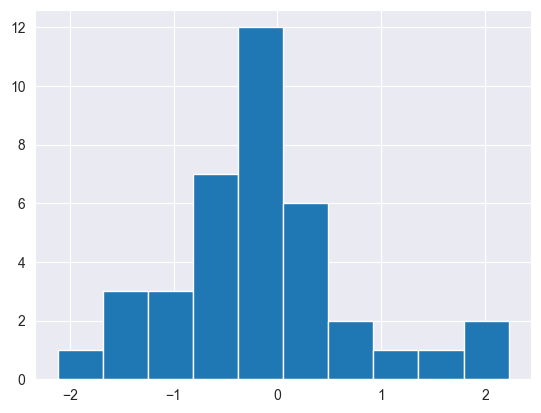

In [286]:
def skew_transformer(dfx_train, dfx_test):
    #initialise the transformer type and run it on the dataframe
    transformer = PowerTransformer(method = 'yeo-johnson')
    transformer.set_output(transform="pandas")
    numeric_cols = dfx_train.select_dtypes(exclude = ['boolean']).columns
    #fit and transform on the train set
    transformed_data = transformer.fit_transform(dfx_train[numeric_cols].astype(float))
    dfx_train[numeric_cols] = transformed_data
    #transorm test set also
    transformed_data = transformer.transform(dfx_test[numeric_cols].astype(float))
    dfx_test[numeric_cols] = transformed_data
    return dfx_train, dfx_test

df_predictor_train, df_predictor_test = skew_transformer(df_predictor_train, df_predictor_test)

# Remove any new 0 variance columns that were create by the transform
def constant_col_drop (dfx_train, dfx_test):
    constant_cols = dfx_train.columns[dfx_train.nunique() <= 1].tolist()
    #print(f"Columns with no variance: {constant_cols}")
    dfx_train.drop(constant_cols, axis = 1, inplace = True)
    dfx_test.drop(constant_cols, axis = 1, inplace = True)
    return dfx_train, dfx_test

df_predictor_train, df_predictor_test = constant_col_drop(df_predictor_train, df_predictor_test)
#Check the skewness post transform
trans_skew = df_predictor_train.select_dtypes(exclude = ['boolean']).skew(numeric_only=True)
print(trans_skew)
plt.hist(trans_skew)

The resulting non-boolean columns have now been transformed to have a skew that ranges from approximately -0.2 to 0.5 rather than from -1 to 6. This should effectively handle the issues identified during EDA with extreme outliers as well as bring the data closer to a normal distribution, which is preferred for machine learning algorithms. This can be checked by replotting the histogram. The new histogram shows a much tighter grouping and closer to normal distribution, but there are still some spiky regions, however all of this skew is now within -2 - 2 range so removing further columns would result more in loss of statistical power than noise reduction.

<Axes: ylabel='Count'>

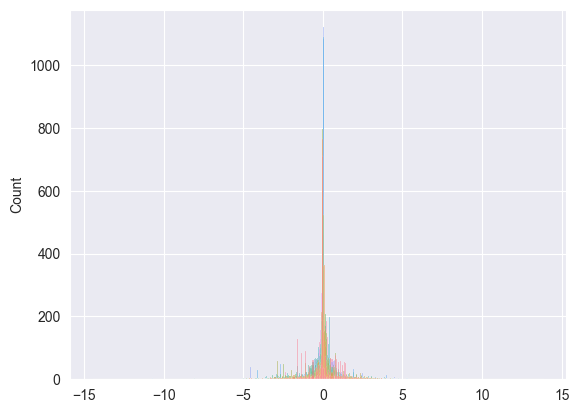

In [287]:
sns.histplot(data=df_predictor_train.select_dtypes(exclude = ['boolean']), legend = False)

### Principal Component Analysis
Principal Component Analysis (PCA) is a form of feature reduction that groups data features together into a larger set of features that mostly explain the variation within the features. It uses eigenvectors and eigenvalues to deconstruct the dataset, with the values corresponding to the variance in a given direction and the vector determining the direction. PCA then analyses the pairs of values and vectors and removes pairs that have the lowest values. The pairs that are removed correspond to a feature (also called a dimension), this effectively reduces the components in the dataset, allowing for the dataset to be simplified *(Dallas. 2017)*. PCA is very sensitive to skew and scale of data. If the PCA is run in the final model, it has to be preceded with the above Yeo-Johnson transform to handle both of these issues in the dataset first.

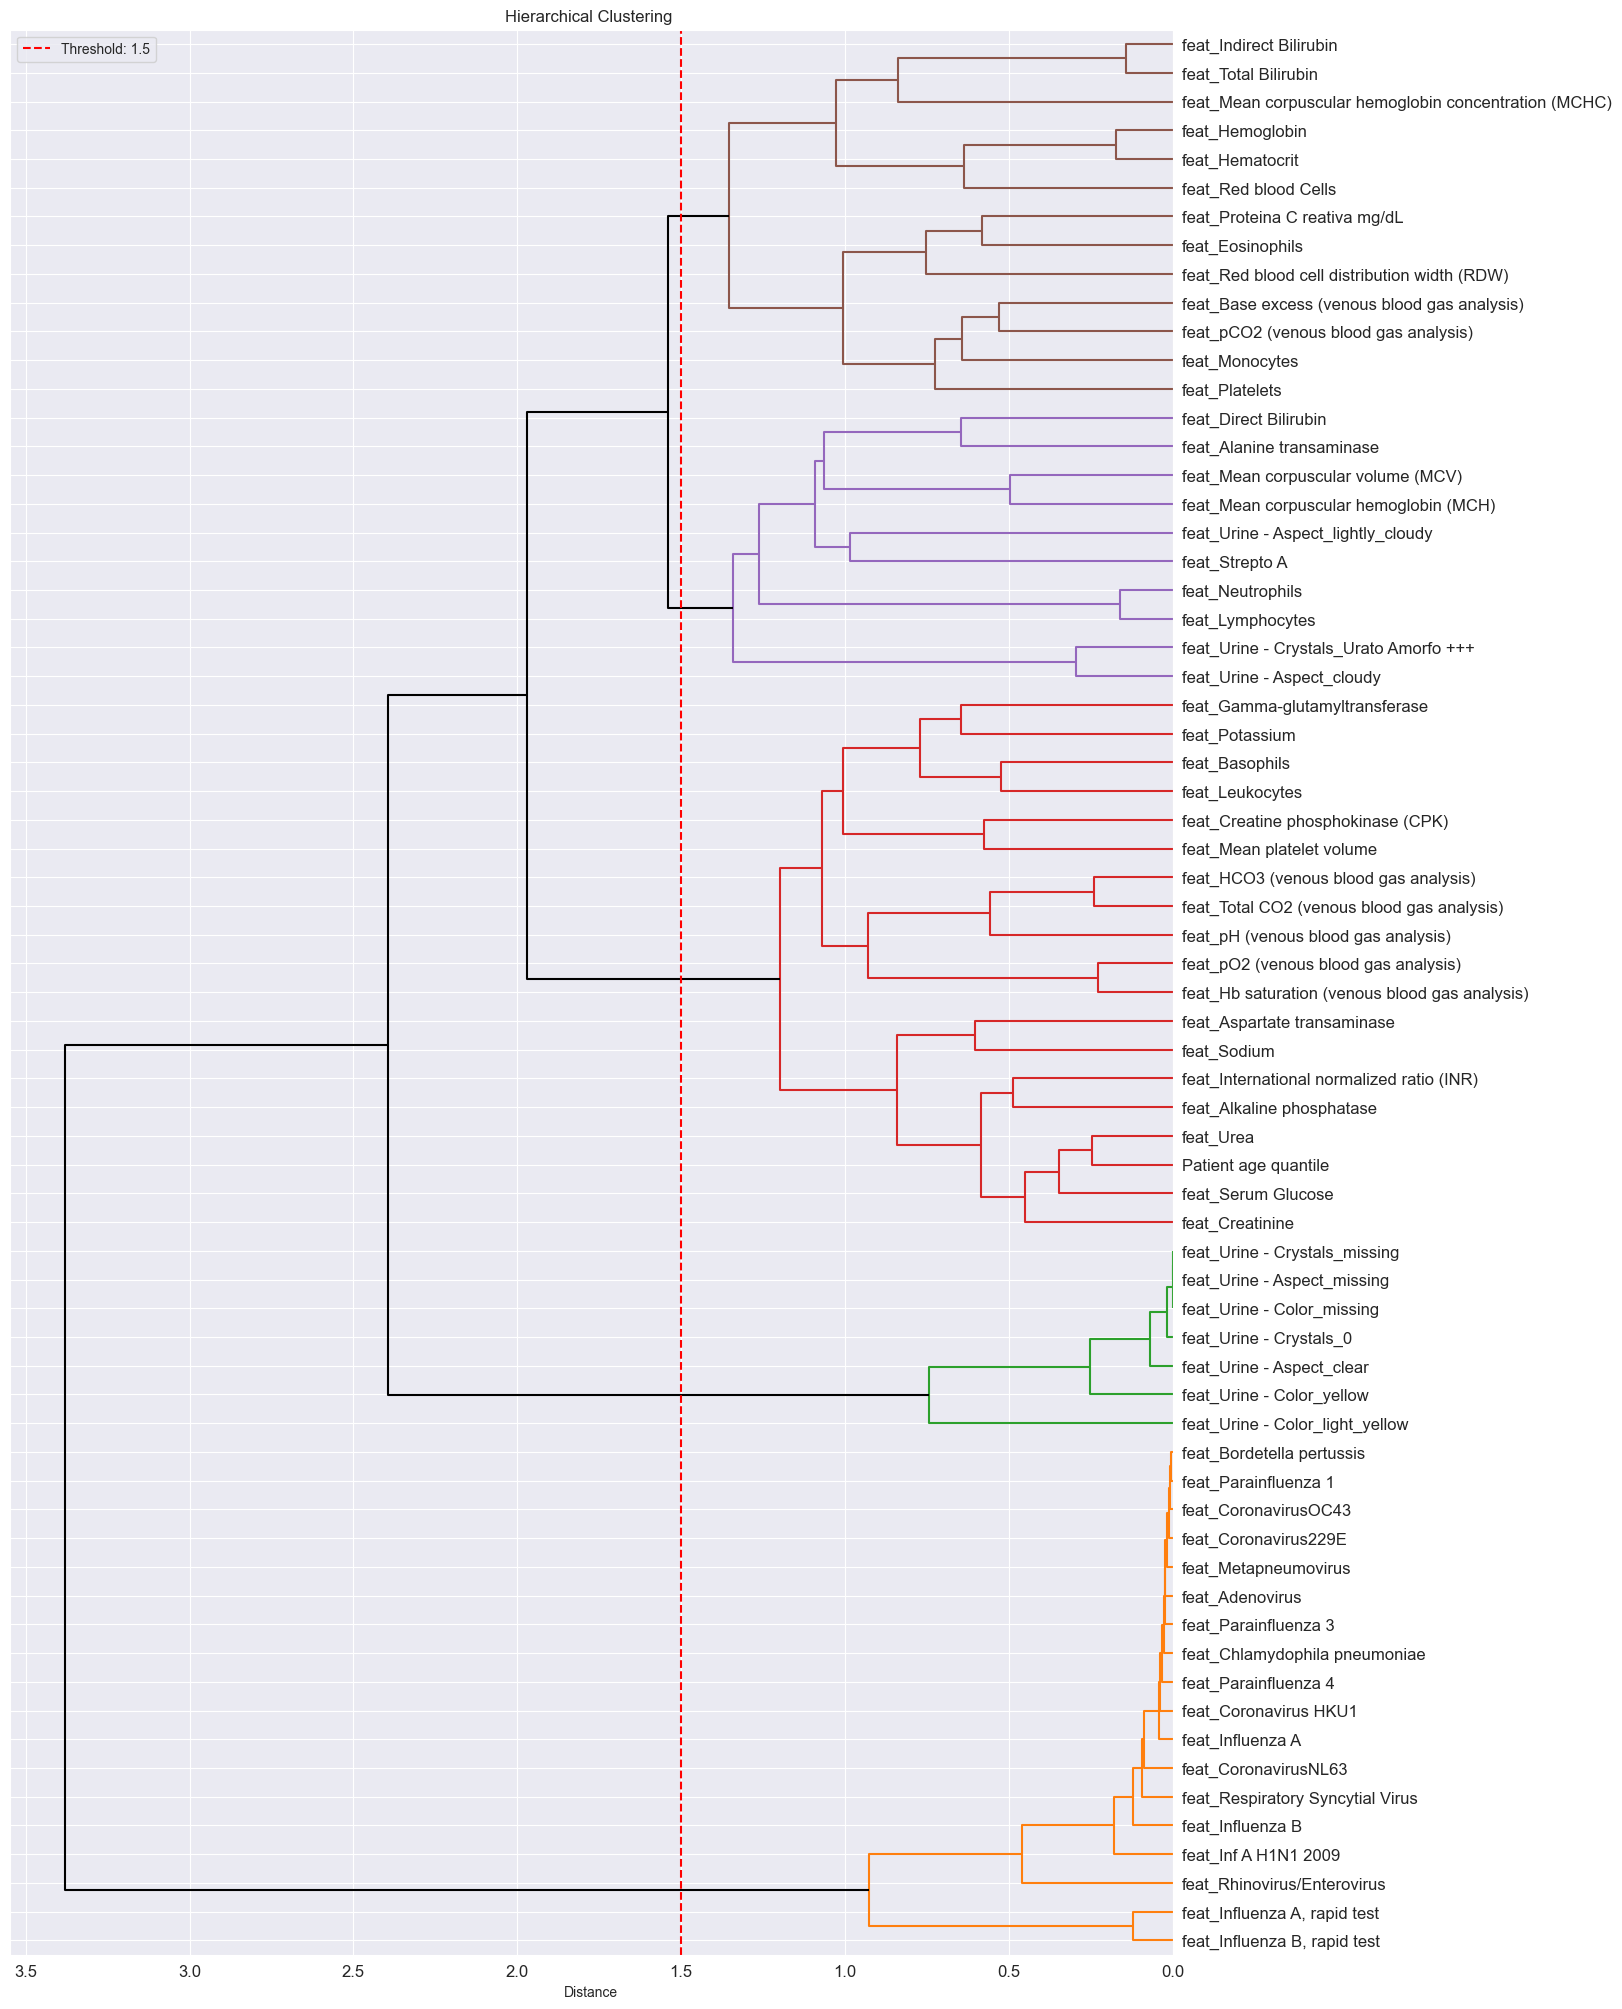

In [288]:
# recreate the correlation matrix and distance matrix from the EDA steps
corr_matrix = df_predictor_train.corr(method = 'spearman').abs()
dist_matrix = 1 - corr_matrix.abs()
condensed_dist = squareform(dist_matrix, checks = False)
# Recluster the data set.
clusters = hierarchy.linkage(condensed_dist, method = 'ward')
plt.figure(figsize=(15, 25))
# calculated iteratively using the below cell's elbow method
threshold = 1.5

# plot fresh dendrogram with threshold and colour code it
colour_cluster_dendrogram = hierarchy.dendrogram(
    clusters,
    labels = corr_matrix.columns,
    orientation = 'left',
    color_threshold = threshold,
    above_threshold_color = 'black'
)

plt.axvline(x = threshold, color = 'red', linestyle = '--', label = f'Threshold: {threshold}')
plt.title('Hierarchical Clustering ', fontsize = 12)
plt.xlabel('Distance')
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.legend(loc = 'upper left')
plt.show()

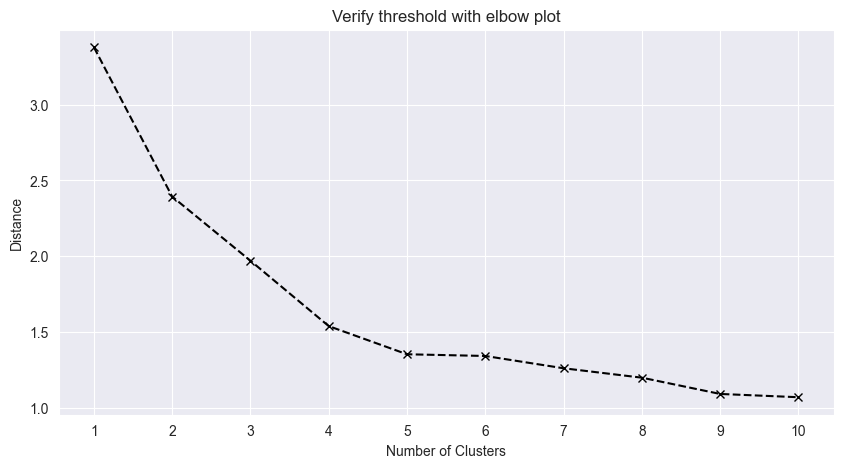

In [289]:
# rerun elbow method check.
distances = clusters[-10:, 2]
distances_rev = distances[::-1]
x_labels = np.arange(1, len(distances) + 1)

plt.figure(figsize = (10, 5))
plt.plot(x_labels, distances_rev, marker = 'x', linestyle = '--', color = 'black')
plt.title('Verify threshold with elbow plot')
plt.xlabel('Number of Clusters')
plt.ylabel('Distance')
plt.xticks(x_labels)
plt.grid(True)
plt.show()

The clustering now shows 5 clusters when thresholded at the elbow point. This will be the starting point for the PCA to run at.

In [290]:
def pca_reduce(dfx_train, dfx_test):
    pca = PCA(n_components = 5)
    pca.set_output(transform = "pandas")
    pca.fit(dfx_train)
    pca_train = pca.transform(dfx_train)
    pca_test = pca.transform(dfx_test)
    return pca_train, pca_test
df_predictor_train, df_predictor_test = pca_reduce(df_predictor_train, df_predictor_test)

### Classifier Imbalance
When the dataset was first read, the summary overview of df_all showed that there were 3598 False and 401 True values a ratio of roughly 90 to 1 (this has changed slightly through dropping columns etc during processing, but the ratio remains mostly unchanged). During iterative testing, linear regression and random forest classifier engines both kept producing multiple false negatives. This is probably due to the extreme imbalance among classifiers. This also made it hard for cross validation methods, such as K-fold, to give accurate reports on the quality of the model. This imbalance needs to be addressed in order to give the model the best chance at accurately predicting the classification of unseen data.

In [291]:
class_counts = df_classifiers.value_counts()
print(class_counts)

SARS-Cov-2 exam result
False    1357
True      138
Name: count, dtype: Int64


The best method for dealing with a class imbalance is to carry out sampling of the dataset. This can be oversampling, where additional entries are added to the dataset for the minority class or undersampling, where the majority class has entries filtered out until the classes are balanced. Both of the sampling methods can be implemented in various ways, and all have drawbacks and advantages.

Oversampling can be achieved through copying random instances of the minority class and adding them to the dataset until a desired class balance is achieved, this can also be done through addition of synthetic oversamples, where a separate algorithm creates new entries for the minority class. There is particular issues with using synthetic generation over sets of data where the algorithm creating the synthetic data is allowing the model to overfit to the synthetic signal, reducing its accuracy on unseen datasets *(Alkhawaldeh et al. 2023)*. However, in the case of this dataset the class imbalance is very pronounced and there is no way to accurately improve it by gathering more data so a synthetic generation approach will be explored.

There is one widely used method for synthetic oversampling called Synthetic Minority Oversampling Technique (SMOTE), which utilises a KNN model to create synthetic data at new points within those KNN intersections *(Brownlee, 2020)*. This is a good blanket approach for synthetic additions but it can introduce overfitting to the model. The method chosen to be used within this model is Adaptive Synthetic Sampling (ADASYN) and it instead creates synthetic samples via SMOTE but with varying densities according to how sparse the regions of feature space are. This introduces a more representative set of synthetic points than the blanket approach of default SMOTE *(Bronwnlee, 2020)*.

In [292]:
def adasyn_oversample(dfx_train, dfy_train):
    # create oversampler, run only on train predictor and train classifier
    adasyn = ADASYN(random_state = 1)
    dfx_over, dfy_over = adasyn.fit_resample(dfx_train, dfy_train)
    return dfx_over, dfy_over
df_classifier_special = df_classifier_train.copy()
df_predictor_train, df_classifier_train = adasyn_oversample(df_predictor_train, df_classifier_train)
df_special_train, df_classifier_special = adasyn_oversample(df_special_train, df_classifier_special)

## Building the Classifier

### Hyperparameter Tuning
The final step in creating a machine learning model is to train either a classifier or a regressor. In the case of this data set where a classification is to be predicted from unseen data, a classifier is used. In the baseline section of the report 3 classifiers were fitted on the mostly unprocessed data set. These models were blind fitted with their default hyperparameters. With the data now processed and transformed, new versions of these models can be fitted and given the test-train splits and cross validation.

As well as data transformation through the processing already carried out, most models have additional hyperparameters that can be adjusted. These parameters set the conditions that the model will train on, they can be as simple as n_jobs which allows balancing of cpu load while running or as complex as reg_alpha for tuning the loss functions in the XGBoost classifier. There are vast combinations of different hyperparameters that can hinder or improve model performance. Hyperparameter tuning is the process of determining which set of parameters gives the best responses on a given training set. Doing so manually could take an extreme amount of time, so there are some core methods for achieving optimisation.

The first method is Grid Search. This utilises a dict of parameter values that are then passed to the model until all possible permutations have been tested. The GridSearchCV then returns the best parameters that were found so future models can use them *(Geeks For Geeks, 2022)*. There are some downsides to this method, it is computationally expensive and lengthy as it runs through parameter combinations one by one, and it also requires some ballpark knowledge of what is likely to be a good parameter in the first instance. It could be that having 20 estimators is the best option for the specific dataset, but if the grid search is only told to look at multiples of 10 from 50 and up, there is no way to find this out without running an additional grid search.

In [ ]:
# WARNING - CPU INTENSE OPERATION - WARNING
params = {
    'n_estimators': [50, 200, 400, 500],
    'max_depth': [None, 10, 20, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1,2, 5],
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_features' : ['sqrt', 'log2']
}
# Run a grid search on all parameters using random state 1, 3 cross validation attempts and utilising all CPU cores.
g_search = GridSearchCV(RandomForestClassifier(random_state = 1), param_grid = params, cv = 3, n_jobs = -1)
g_search.fit(df_predictor_train, df_classifier_train)

g_search.best_params_

The second method for hyperparameter tuning is RandomizedSearch. This method searches the same parameter grid in a random fashion, rather than combing through exhaustively. This means it runs much faster on average than a full grid search, but may not find the exact correct parameter combination as grid search does. It runs for as many iterations as specified and will carry out cross validations the same way a grid search does. RandomizeSearch can also be provided with probabilities for some of the values, such as the estimators and depths and search through parameters within the specified distributions *(Attard, 2025)*

In [293]:
params = {
    'n_estimators': [50, 200, 400, 500],
    'max_depth': [None, 10, 20, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy'],
    'max_features' : ['sqrt', 'log2']
}
#Run a randomised search on all parameters using random state 1, 3 cross validation attempts, 10 maximum iterations and utilising all CPU cores.
r_search = RandomizedSearchCV(BalancedRandomForestClassifier(random_state = 1), params, n_jobs = -1, cv = 3, n_iter = 10)
r_search.fit(df_predictor_train, df_classifier_train)
r_search.best_params_

{'n_estimators': 400,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 50,
 'criterion': 'gini',
 'bootstrap': True}

In [294]:
params = {
    'n_neighbors': [5,8, 10, 20, 50],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'leaf_size': [10, 20,30, 40, 50],
    'p': [1, 2]
}

r_search_knn = RandomizedSearchCV(KNeighborsClassifier(n_jobs= -1), params, n_jobs = -1, cv = 3, n_iter = 10)
r_search_knn.fit(df_predictor_train, df_classifier_train)
r_search_knn.best_params_

{'weights': 'distance',
 'p': 1,
 'n_neighbors': 10,
 'leaf_size': 20,
 'algorithm': 'auto'}

The final method is utilising Bayes Theorem for non-categorical hyperparameters. This is similar to using randomised search over probabilities, but uses Bayes theorem for picking permutations of parameters. This is more advanced and can give highly specific float values to pass as hyperparameters, but also requires careful choosing of the probability distributions to attain reliable results. These probablities are based on how much a change of certain magnitude makes to a hyperparameter. The log-uniform specification for example is for when the order of magnitude matters more than the specific value and uniform goes through the distribution linearly, which is better for short rangers of integers like within depth and samples parameters *(Attard, 2025 & Bolstad et al., 2016)*. This kind of search is useful when there are parameters that have different magnitudes, can take Real numbers or Floats as inputs and it is much lighter computationally than full grid searches.

In [295]:
params = {
    'n_estimators': Integer(50,500, prior = 'uniform'),
    'learning_rate': Real(0.01,2, prior = 'log-uniform'),
    'max_depth': Integer(1,50, prior = 'uniform'),
    'reg_alpha': Real(0.01,2, prior = 'log-uniform'),
    'reg_lambda': Real(0.01,2, prior = 'log-uniform')
}
# run a Bayesian Search for all parameters with random_state 1, 3 cross validation attempts, 10 iterations and all cpu cores.
b_search = BayesSearchCV(XGBClassifier(random_state = 1), params, n_jobs = -1, cv = 3, n_iter = 10)
b_search.fit(df_predictor_train, df_classifier_train)
b_search.best_params_

OrderedDict([('learning_rate', 0.35872162619893017),
             ('max_depth', 44),
             ('n_estimators', 327),
             ('reg_alpha', 0.3422812581216681),
             ('reg_lambda', 1.4191604187417135)])

** NOTE: running the above hyperparameter tuning is likely to produce different results each time due to the random nature of the search methods **
### Model selection
Now the parameters are identified via the various search methods grid, they can be input into a model which is subsequently fitted with the training data set. This is run on the current test train split and also cross validated as with the baseline models.

In [296]:
def cross_val_processor(raw_predictors, raw_classifiers, skew_trans = True, constant_drop = True, pca_reduction = True, missing_thresh = True):
    skf_cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 1)
    processed_splits = {}
    for i, (train_index, test_index) in enumerate(skf_cv.split(raw_predictors, raw_classifiers), 1):
        x_train, x_test = raw_predictors.iloc[train_index].copy(), raw_predictors.iloc[test_index].copy()
        y_train, y_test = raw_classifiers.iloc[train_index].copy(), raw_classifiers.iloc[test_index].copy()
        # Carry out additional processing steps laid out in the report in order.
        x_train, x_test, enc = one_hot_encoder(x_train, x_test)
        if missing_thresh:
            x_train, x_test, trans = missingness_thresholder(x_train, x_test, 0.03)
        x_train, x_test, imp, bools = missingness_imputer(x_train, x_test, imputer_type = 'iterative', imputer_strategy= 'median')
        if skew_trans:
            x_train, x_test = skew_transformer(x_train, x_test)
        if constant_drop:
            x_train, x_test = constant_col_drop(x_train, x_test)
        if pca_reduction:
            x_train, x_test = pca_reduce(x_train, x_test)
        x_train, y_train = adasyn_oversample(x_train, y_train)

        processed_splits[f'Split_{i}'] = (x_train, x_test, y_train, y_test)
    return processed_splits

Iterative imputation
Iterative imputation
Iterative imputation


C:\Users\Jess\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Iterative imputation
Iterative imputation
Model RandomForestClassifier cross val fold score is 
0.5520701853442651
Model XGBClassifier cross val fold score is 
0.5421706660790392
Model BalancedRandomForestClassifier cross val fold score is 
0.547355351919401
Model KNeighborsClassifier cross val fold score is 
0.5137840844234806
RandomForestClassifier score is 
0.822742474916388
RandomForestClassifier f1 is 
0.5545717738988672


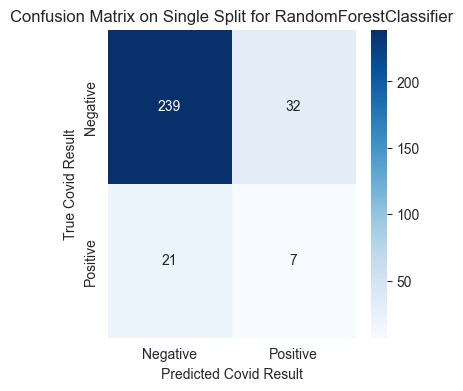

XGBClassifier score is 
0.7993311036789298
XGBClassifier f1 is 
0.537342686197648


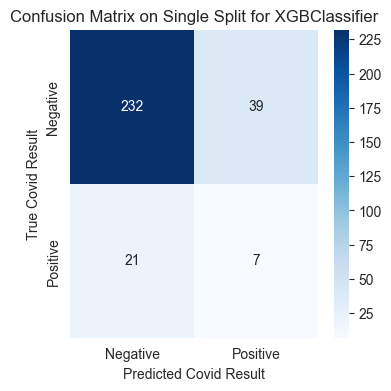

BalancedRandomForestClassifier score is 
0.8093645484949833
BalancedRandomForestClassifier f1 is 
0.5553033268101761


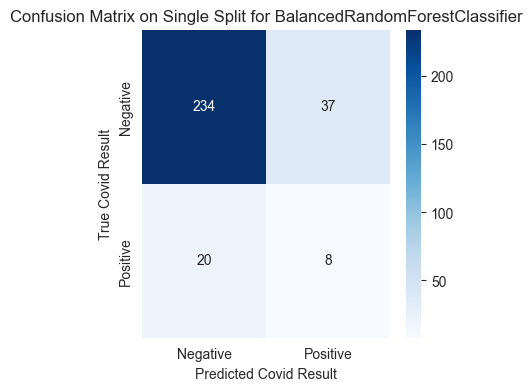

KNeighborsClassifier score is 
0.7792642140468228
KNeighborsClassifier f1 is 
0.533607487237663


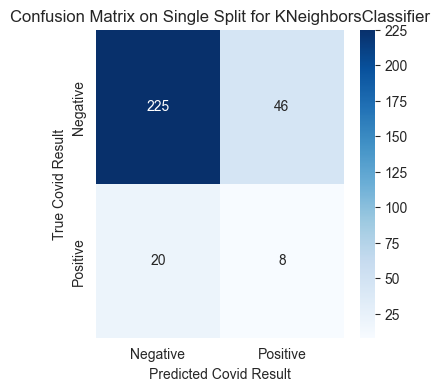

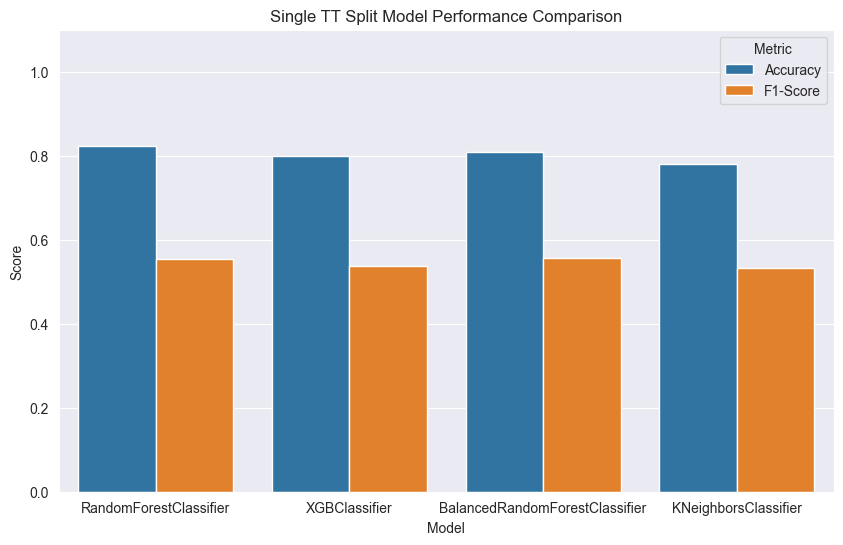

,Model,Accuracy,F1-Score
0,RandomForestClassifier,0.822742,0.554572
1,XGBClassifier,0.799331,0.537343
2,BalancedRandomForestClassifier,0.809365,0.555303
3,KNeighborsClassifier,0.779264,0.533607


In [297]:
# Create classifiers using the best params identified by the above hyperparameter tuning
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 1)
results = {}
fitted_models = []
unfitted_models = [
    RandomForestClassifier(random_state = 1,
                           bootstrap = False,
                           max_depth = None,
                           min_samples_split = 2,
                           min_samples_leaf = 1,
                           n_estimators = 400,
                           criterion = 'gini',
                           max_features = 'sqrt',
                           n_jobs = -1),
    XGBClassifier(random_state = 1,
                  learning_rate = 0.4885618130485042,
                  n_estimators = 96,
                  max_depth = 21,
                  reg_alpha = 0.35548451639070244,
                  reg_lambda= 0.013646264143933466),
    BalancedRandomForestClassifier(random_state = 1,
                                   n_estimators = 400,
                                   min_samples_split= 2,
                                   min_samples_leaf = 1,
                                   max_features = 'sqrt',
                                   max_depth = 50,
                                   criterion = 'entropy',
                                   bootstrap = False,
                                   n_jobs = -1 ),
    KNeighborsClassifier(n_neighbors = 5,
                         p = 2,
                         leaf_size = 40,
                         algorithm = 'kd_tree',
                         weights = 'distance',
                         n_jobs = -1)
]

# Split raw data into folds and apply new processing logic to folds before running models on each fold
processed_splits = cross_val_processor(df_predictors,df_classifiers)

for model in unfitted_models:
    model_name = model.__class__.__name__
    fold_scores = []
    for split_name, (x_train, x_test, y_train, y_test) in processed_splits.items():
        model.fit(x_train, y_train)
        predictions = model.predict(x_test)
        fold_scores.append(f1_score(y_test, predictions, average = 'macro'))
    results[model_name] = np.mean(fold_scores)
    print(f'Model {model_name} cross val fold score is \n{results[model_name]}')

for unfitted_model in unfitted_models:
    unfitted_model.fit(df_predictor_train, df_classifier_train)
    fitted_models.append(unfitted_model)
compare_models(fitted_models, df_predictor_test, df_classifier_test)



With the above tests run, it seems like the processing work has resulted in a decline of both F1 scores and accuracy. This means that some important features are likely being lost or transformed too far during the processing operations. This is shown with the cross validated mean F1 score for all models being around 0.5 lower when trained on the processed data vs trained on the minimally processed dataset during the baseline modeling section. One of the possible reasons for this is although PCA does reduce features significantly it could be losing a key distinct feature somewhere in the transformation. Re-running the models with various processing steps enabled or disabled or performing further hyperparameter tuning for the processing steps themselves would likely result in an increase of the F1 score and the accuracy of the models. As PCA is a likely cause of underfitting for this model, disabling it and running the model pipelines again should show an improvement in F1 and accuracy at the cross validated level.

Iterative imputation
Iterative imputation
Iterative imputation


C:\Users\Jess\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Iterative imputation
Iterative imputation
Model RandomForestClassifier cross val fold score is 
0.5805341827913598
Model XGBClassifier cross val fold score is 
0.5942971933596982
Model BalancedRandomForestClassifier cross val fold score is 
0.6043867637771994
Model KNeighborsClassifier cross val fold score is 
0.538264333991335
RandomForestClassifier score is 
0.842809364548495
RandomForestClassifier f1 is 
0.5134845075298599


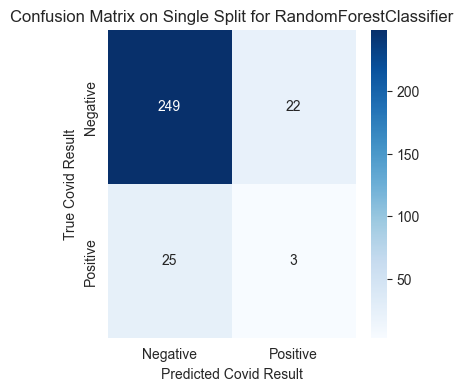

XGBClassifier score is 
0.8160535117056856
XGBClassifier f1 is 
0.5709067188519243


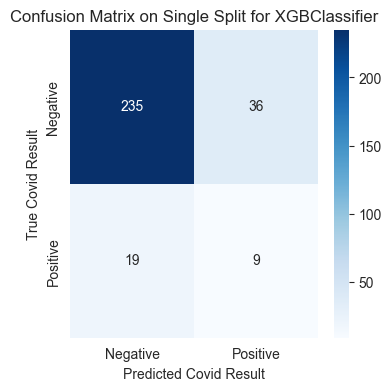

BalancedRandomForestClassifier score is 
0.842809364548495
BalancedRandomForestClassifier f1 is 
0.5580956573692651


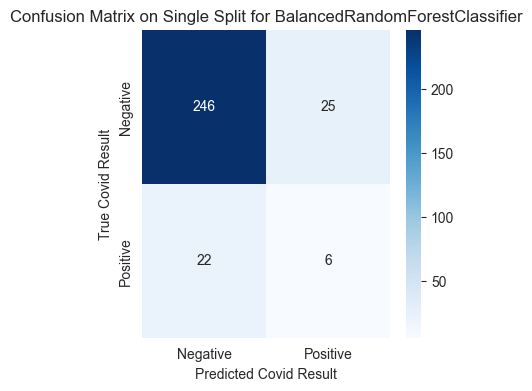

KNeighborsClassifier score is 
0.725752508361204
KNeighborsClassifier f1 is 
0.5432563338301043


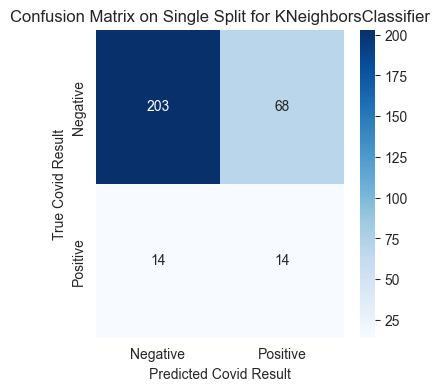

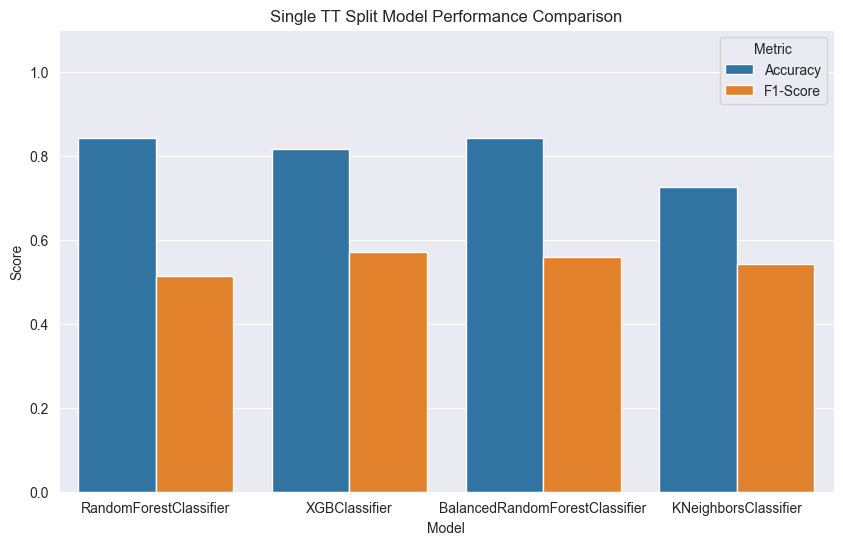

,Model,Accuracy,F1-Score
0,RandomForestClassifier,0.842809,0.513485
1,XGBClassifier,0.816054,0.570907
2,BalancedRandomForestClassifier,0.842809,0.558096
3,KNeighborsClassifier,0.725753,0.543256


In [223]:
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 1)
results = {}
fitted_models = []
model_out = {}
unfitted_models = [
    RandomForestClassifier(random_state = 1,
                           bootstrap = False,
                           max_depth = None,
                           min_samples_split = 2,
                           min_samples_leaf = 1,
                           n_estimators = 400,
                           criterion = 'gini',
                           max_features = 'sqrt',
                           n_jobs = -1),
    XGBClassifier(random_state = 1,
                  learning_rate = 0.4885618130485042,
                  n_estimators = 96,
                  max_depth = 21,
                  reg_alpha = 0.35548451639070244,
                  reg_lambda= 0.013646264143933466),
    BalancedRandomForestClassifier(random_state = 1,
                                   n_estimators = 400,
                                   min_samples_split= 2,
                                   min_samples_leaf = 1,
                                   max_features = 'sqrt',
                                   max_depth = 50,
                                   criterion = 'entropy',
                                   bootstrap = False,
                                   n_jobs = -1 ),
    KNeighborsClassifier(n_neighbors = 5,
                         p = 2,
                         leaf_size = 40,
                         algorithm = 'kd_tree',
                         weights = 'distance',
                         n_jobs = -1)
]

# Split raw data into folds and apply new processing logic to folds before running models on each fold
processed_splits = cross_val_processor(df_predictors,df_classifiers,
                                       skew_trans = False,
                                       constant_drop = False,
                                       pca_reduction= False)

for model in unfitted_models:
    model_name = model.__class__.__name__
    fold_scores = []
    for split_name, (x_train, x_test, y_train, y_test) in processed_splits.items():
        model.fit(x_train, y_train)
        predictions = model.predict(x_test)
        fold_scores.append(f1_score(y_test, predictions, average = 'macro'))
    results[model_name] = np.mean(fold_scores)
    print(f'Model {model_name} cross val fold score is \n{results[model_name]}')

for unfitted_model in unfitted_models:
    unfitted_model.fit(df_special_train, df_classifier_special)
    fitted_models.append(unfitted_model)
    model_out[unfitted_model.__class__.__name__] = unfitted_model
compare_models(fitted_models, df_special_test, df_classifier_test)

With the new models showing markedly improved F1 Scores when cross validated with the Skew transformations and PCA removed, it is likely that too much information was being lost from the dataset during these steps. The new results suggested that the BalancedForest model fitted with this limited processing dataset and the tuned hyperparameters will be the best classifier for the unseen set. Therefore, it will be used to generate the final predictions.

## Predicting the Unseen data

now the unseen data needs to be prepared in an identical fashion to the training data. All columns and rows that are dropped must also be dropped, any encoding or transformations must be applied to the unseen data also by the transformers that were trained on the training set. During the import and processing of the unseen data it was observed that there were some values that were not present during training, such as 'FALSE' in a column that was previously empty or additional categories in categoric columns. These had to be removed and handled as the model expects an exactly identical number and type of columns in order to predict the classifications.

In [262]:
#load the schema - There is a rouge FALSE in a column that was fully NaN in the training set, therefore the old schema fails
with open('unseen_ingest_schema.json') as f:
    schema = json.load(f)
# Load the unseen set:
df_unseen = pd.read_csv(
    filepath_or_buffer ="COVID_TestData.csv",
    dtype=schema,
    true_values = ["positive", "detected", "TRUE", 'present'],
    false_values = ["negative", "not_detected", "FALSE", 'absent'],
    na_values = ["not_done", "NA"],
    on_bad_lines = "warn"
    )
#Clean the column headers
df_unseen = clean_cols(df_unseen)
# Apply the standard fixed pre-processing
df_unseen.drop('Patient ID', inplace = True, axis = 1)
df_unseen.drop(columns = single_values, inplace = True)
df_unseen = input_mapping(df_unseen)
converted_data = df_unseen[categorical_cols].astype(str).replace('nan', 'missing')
encoded_data = encoder.transform(converted_data)
encoded_cols = encoder.get_feature_names_out(categorical_cols)
df_unseen_encoded = pd.DataFrame(encoded_data, columns = encoded_cols, index = df_unseen.index)
df_unseen_encoded = df_unseen.drop(columns = categorical_cols).join(df_unseen_encoded)
df_unseen_encoded = df_unseen_encoded.drop(columns = ['feat_Urine - Color_citrus_yellow', 'feat_Urine - Crystals_Oxalato de Cálcio +++', 'feat_Urine - Crystals_Oxalato de Cálcio -++']) # additional column results for onehot encoded data - dropped as not appearing in any fitting.
# predict baseline model here:
baseline_classifier = baseline_model_out['BalancedRandomForestClassifier']
baseline_final_predictions = baseline_classifier.predict(df_unseen_encoded)
baseline_results_df = pd.DataFrame(baseline_final_predictions, index = df_unseen_encoded.index, columns = ['Predicted label'])
baseline_results_df.to_csv('baseline_results_df.csv', index = True)
# additional processing
df_unseen_encoded.drop(df_unseen_encoded.columns.difference(threshold_keep_cols), axis = 1, inplace = True)
df_unseen_imputed = missing_imputer.transform(df_unseen_encoded)
df_unseen_imputed[boolean_cols] = df_unseen_imputed[boolean_cols].astype(bool)

# testing shows that no skew or pca should be applied so retrieve the model that was fitted in this way.
classifier = model_out['BalancedRandomForestClassifier']
final_predictions = classifier.predict(df_unseen_imputed)
results_df = pd.DataFrame(final_predictions, index = df_unseen_imputed.index, columns = ['Predicted label'])
results_df.to_csv('Final_Model_Predictions.csv', index = True)

C:\Users\Jess\AppData\Local\Temp\ipykernel_32812\3666694542.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(mapping)
C:\Users\Jess\AppData\Local\Temp\ipykernel_32812\3666694542.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(mapping)


The predictions are converted to dataframes so that they can be exported as CSV files. The files will be in the git repo and have also been copied to the forms uploaded to blackboard.
## Conclusions and Reflections
Overall I feel that I struggled to know what methods to apply to get the best possible predictions out of the unseen data. I carried out initial EDA early into the project, but it was definitely not substantial enough. This led to me returning back to the EDA section after working on the model without any direction for several weeks. Once I carried out proper EDA including the visuals I generated, it helped direct the data processing efforts I was making. There is also an overwhelming amount of choices available for data mining, with myriad libraries, extensions and plugins available. While carrying out significant research into the topic outside what was included within the webinars, labs and recommended reading I got confused by conflicting information, such as SMOTE is excellent for imbalanced sets but is not good enough for medical datasets. This led to me adding and removing functions from my work, building 3 separate notebooks to test different ideas and losing sight of the main goal of the module.

I was also confused as to why after all the processing work, that the F1 scores were not improving or barely improving meaningfully. I think that this is mostly down to how poor the dataset actually is. It is 90% empty and has a massive class imbalance. Had I had expert medical knowledge, feature reductions could have been done by extracting what are likely to be the key indicators of a viral infection rather than trying to rely on PCA to carry that out for me.

On the other hand I think I still created a robust datamining project, that considers all the requirements of the brief, and I was able to return improved F1 scores for the BalancedForest classifier that I chose to use out of all the other models. Given more time I think other models like XGBoost could have provided better results in the long run if tuning the processing was focused solely on it and not providing the best baseline for multiple models. The reason I chose that approach is because I was unsure which model could handle this dataset the best. KNN has known limitations of not being able to handle NaN values at all, whereas the other models I chose to use all have inbuilt NaN handling as well as gradient boosting features for sparsity and class imbalance in the case of XGboost.

I also had multiple issues with data leakage during the project, where my F1 scores were jumping up massively after I made some changes, and I was content to continue with that until I learned after further study and review that there is a large pitfall of carrying out cross validation on already transformed data. The folds already have knowledge of each other as a result of the processing, causing massively inflated and overfitted cross validation scores. Once I built a robust cross validation function it was much easier to see the true F1 scores that I was getting and I was able to tune the model accordingly from there.

In summary, the project was challenging and overwhelming to start with, but I feel confident that I produced a strong pipeline which will provide the most accurate results possible given the poor quality nature of the input dataset.
## References

* Holdsworth, J. (2024). What is data mining? [online] Ibm.com. Available at: https://www.ibm.com/think/topics/data-mining
* GeeksforGeeks (2018). Basic Concept of Classification (Data Mining). [online] GeeksforGeeks. Available at: https://www.geeksforgeeks.org/machine-learning/classification-in-data-mining/
* Pillai, P. (2023). Attributes in Data Science. [online] Medium. Available at: https://medium.com/@poojapillai044/attributes-in-data-science-9c96f16124eb
* Pandas (2019). Python Data Analysis Library — pandas: Python Data Analysis Library. [online] Pydata.org. Available at: https://pandas.pydata.org
* Kang, H. (2013). The Prevention and Handling of the Missing Data. Korean Journal of Anesthesiology, [online] 64(5), pp.402–406. doi:https://doi.org/10.4097/kjae.2013.64.5.402
* Kaneko, J.J., Harvey, J.W. and Bruss, M.L. (2008). Clinical Biochemistry of Domestic Animals. 6th ed. Amsterdam: Elsevier. ISBN: 978-0-12-370491-7
* Sharma, R. (2022). What is Skewed Data and How Is It Effecting Your Statistical Model? | Built In. [online] builtin.com. Available at: https://builtin.com/data-science/skewed-data
* Brownlee, J. (2020). How to Use Power Transforms for Machine Learning - MachineLearningMastery.com. [online] MachineLearningMastery.com. Available at: https://machinelearningmastery.com/power-transforms-with-scikit-learn/
* Mucci, T. (2024). Data leakage machine learning. [online] Ibm.com. Available at: https://www.ibm.com/think/topics/data-leakage-machine-learning
* Rojo-Echeburúa, A. (2024). What Is One Hot Encoding and How to Implement It in Python. [online] Datacamp.com. Available at: https://www.datacamp.com/tutorial/one-hot-encoding-python-tutorial
* Noble, J. (2024). Hierarchical clustering. [online] Ibm.com. Available at: https://www.ibm.com/think/topics/hierarchical-clustering#2142864943
* Ferreira, L. and Hitchcock, D.B. (2009). A Comparison of Hierarchical Methods for Clustering Functional Data. Communications in Statistics - Simulation and Computation, 38(9), pp.1925–1949. doi:https://doi.org/10.1080/03610910903168603
* Geiser, C (2025). Missing Data Mechanisms Explained. [online] YouTube. Available at: https://www.youtube.com/watch?v=h2dOKH5aLFg
* Brownlee, J. (2013). How to Identify Outliers in your Data - MachineLearningMastery.com. [online] MachineLearningMastery.com. Available at: https://machinelearningmastery.com/how-to-identify-outliers-in-your-data/
* Näf, J. (2024). What Is a Good Imputation for Missing Values? | Towards Data Science. [online] Towards Data Science. Available at: https://towardsdatascience.com/what-is-a-good-imputation-for-missing-values-e9256d45851b/
* GeeksforGeeks (2025). Yeo Johnson Transform. [online] GeeksforGeeks. Available at: https://www.geeksforgeeks.org/machine-learning/yeo-johnson-transform/
* Strahl, R. (2018). Getting Images into Markdown Documents and Weblog Posts with Markdown Monster. [online] Medium. Available at: https://medium.com/markdown-monster-blog/getting-images-into-markdown-documents-and-weblog-posts-with-markdown-monster-9ec6f353d8ec.
* Dallas, G. (2017). Principal Component Analysis 4 Dummies: Eigenvectors, Eigenvalues and Dimension Reduction. [online] George Dallas. Available at: https://georgemdallas.wordpress.com/2013/10/30/principal-component-analysis-4-dummies-eigenvectors-eigenvalues-and-dimension-reduction/
* Alkhawaldeh, I.M., Albalkhi, I. and Naswhan, A.J. (2023). Challenges and limitations of synthetic minority oversampling techniques in machine learning. World Journal of Methodology, 13(5), pp.373–378. doi:https://doi.org/10.5662/wjm.v13.i5.373
* Brownlee, J. (2020). SMOTE for Imbalanced Classification with Python. [online] Machine Learning Mastery. Available at: https://machinelearningmastery.com/smote-oversampling-for-imbalanced-classification/
* GeeksforGeeks (2022). Random Forest Hyperparameter Tuning in Python. [online] GeeksforGeeks. Available at: https://www.geeksforgeeks.org/machine-learning/random-forest-hyperparameter-tuning-in-python/
* Attard, M. (2025). 3 Popular Ways for Hyperparameter Tuning with Random Forest - Inside Learning Machines. [online] Available at: https://insidelearningmachines.com/hyperparameter_tuning_with_random_forest/
* Bolstad, W.M. and Curran, J.M. (2016). Introduction to Bayesian Statistics. John Wiley & Sons